In [2]:
from tqdm import trange
import numpy as np
from scipy.stats import powerlaw, poisson, binned_statistic
from scipy.optimize import minimize
from scipy.interpolate import interp1d
import matplotlib as mpl
import matplotlib.pyplot as plt
plt.style.use('sans.mplstyle')

from astropy.io import fits
import astropy.units as u
import astropy.coordinates as coord
from astropy.coordinates import frame_transform_graph
from astropy.coordinates.matrix_utilities import matrix_transpose, rotation_matrix

from ezpadova import parsec

import gala.coordinates as gc
import gala.dynamics as gd
import gala.potential as gp
from gala.units import galactic
from gala.dynamics import mockstream as ms
_ = coord.galactocentric_frame_defaults.set('v4.0')

import agama
agama.setUnits(length=1, velocity=1, mass=1)

In [2]:
# For agama streams

# Useful utility functions

def get_rot_mat(x, y, z, vx, vy, vz):
    Lx = y * vz - z * vy
    Ly = z * vx - x * vz
    Lz = x * vy - y * vx
    r = (x*x + y*y + z*z)**0.5
    L = (Lx*Lx + Ly*Ly + Lz*Lz)**0.5
    # rotation matrices transforming from the host to the satellite frame for each point on the trajectory
    R = np.zeros((len(x), 3, 3))
    R[:,0,0] = x/r
    R[:,0,1] = y/r
    R[:,0,2] = z/r
    R[:,2,0] = Lx/L
    R[:,2,1] = Ly/L
    R[:,2,2] = Lz/L
    R[:,1,0] = R[:,0,2] * R[:,2,1] - R[:,0,1] * R[:,2,2]
    R[:,1,1] = R[:,0,0] * R[:,2,2] - R[:,0,2] * R[:,2,0]
    R[:,1,2] = R[:,0,1] * R[:,2,0] - R[:,0,0] * R[:,2,1]
    return R, L, r

def get_d2Phi_dr2(pot_host, x, y, z):
    # compute  the second derivative of potential by spherical radius
    r = (x*x + y*y + z*z)**0.5
    der = pot_host.forceDeriv(np.column_stack([x,y,z]))[1]
    d2Phi_dr2 = -(x**2  * der[:,0] + y**2  * der[:,1] + z**2  * der[:,2] +
                  2*x*y * der[:,3] + 2*y*z * der[:,4] + 2*z*x * der[:,5]) / r**2
    return d2Phi_dr2

def create_ic_chen24(rng, pot_host, orb_sat, mass_sat):
    N = len(orb_sat)
    x, y, z, vx, vy, vz = orb_sat.T
    R, L, r = get_rot_mat(x, y, z, vx, vy, vz)
    d2Phi_dr2 = get_d2Phi_dr2(pot_host, x, y, z)
    
    # compute the tidal radius at this radius for each point on the trajectory
    Omega = L / r**2
    r_tidal = (agama.G * mass_sat / (Omega**2 - d2Phi_dr2))**(1./3)
    
    # assign positions and velocities (in the satellite reference frame) of particles
    r_tidal = np.repeat(r_tidal, 2)

    mean = np.array([1.6, -30, 0, 1, 20, 0])

    cov = np.array([
        [0.1225,   0,   0, 0, -4.9,   0],
        [     0, 529,   0, 0,    0,   0],
        [     0,   0, 144, 0,    0,   0],
        [     0,   0,   0, 0,    0,   0],
        [  -4.9,   0,   0, 0,  400,   0],
        [     0,   0,   0, 0,    0, 484],
    ])
    
    posvel = rng.multivariate_normal(mean, cov, size=2*N)

    Dr = posvel[:, 0] * r_tidal
    v_esc = np.sqrt(2 * agama.G * mass_sat / Dr)
    Dv = posvel[:, 3] * v_esc

    # convert degrees to radians
    phi = posvel[:, 1] * np.pi / 180
    theta = posvel[:, 2] * np.pi / 180
    alpha = posvel[:, 4] * np.pi / 180
    beta = posvel[:, 5] * np.pi / 180

    dx = Dr * np.cos(theta) * np.cos(phi)
    dy = Dr * np.cos(theta) * np.sin(phi)
    dz = Dr * np.sin(theta)
    dvx = Dv * np.cos(beta) * np.cos(alpha)
    dvy = Dv * np.cos(beta) * np.sin(alpha)
    dvz = Dv * np.sin(beta)

    dq = np.column_stack([dx, dy, dz])
    dp = np.column_stack([dvx, dvy, dvz])
    
    ic_stream = np.tile(orb_sat, 2).reshape(2*N, 6)
    
    # trailing arm
    ic_stream[::2,0:3] += np.einsum('ni,nij->nj', dq[::2], R)
    ic_stream[::2,3:6] += np.einsum('ni,nij->nj', dp[::2], R)
    
    # leading arm
    ic_stream[1::2,0:3] += np.einsum('ni,nij->nj', -dq[1::2], R)
    ic_stream[1::2,3:6] += np.einsum('ni,nij->nj', -dp[1::2], R)

    return ic_stream

def create_stream(create_ic_method, rng, time_total, num_particles, pot_host, posvel_sat, mass_sat, pot_sat=None, **kwargs):
    # integrate the orbit of the progenitor from its present-day posvel (at time t=0)
    # back in time for an interval time_total, storing the trajectory at num_steps points
    time_sat, orbit_sat = agama.orbit(potential=pot_host, ic=posvel_sat,
        time=time_total, trajsize=num_particles//2)
    if time_total < 0:
        # reverse the arrays to make them increasing in time
        time_sat  = time_sat [::-1]
        orbit_sat = orbit_sat[::-1]

    # at each point on the trajectory, create a pair of seed initial conditions
    # for particles released at Lagrange points
    ic_stream = create_ic_method(rng, pot_host, orbit_sat, mass_sat, **kwargs)
    time_seed = np.repeat(time_sat, 2)
    
    if pot_sat is None:
        pot_tot = pot_host
    else:
        # include the progenitor's potential
        traj = np.column_stack([time_sat, orbit_sat])
        pot_traj = agama.Potential(potential=pot_sat, center=traj)
        pot_tot = agama.Potential(pot_host, pot_traj)
        
    dur = -time_seed if time_total<0 else time_total-time_seed
    ic_stream = ic_stream[dur>0]
    time_seed = time_seed[dur>0]
    xv_stream = np.vstack(agama.orbit(potential=pot_tot,
        ic=ic_stream, time=dur[dur>0], timestart=time_seed, trajsize=1)[:,1])
    return time_sat, orbit_sat, xv_stream, ic_stream, time_seed

## Ibata+21 catalog

[ADS link](https://ui.adsabs.harvard.edu/abs/2021ApJ...914..123I/abstract)

In [3]:
dtype = {
    'names':   ('star_id', 'ra', 'dec', 'plx', 'mu_ra', 'mu_dec', 'G',  'BP-RP', 'd',  'vr', 'evr', 'rvr', 'stream_id'),
    'formats': ('i8',      'f8', 'f8',  'f8',  'f8',    'f8',     'f8', 'f8',    'f8', 'f8', 'f8',  'i8' , 'i8'       )}

d = np.loadtxt('../data/apjabfcc2t1_mrt.txt', dtype=dtype, skiprows=41)

## Ibata+24 catalog

[ADS link](https://ui.adsabs.harvard.edu/abs/2024ApJ...967...89I/abstract)

In [242]:
dtype = {
    'names':   ('star_id', 'ra', 'dec', 'plx', 'mu_ra', 'mu_dec', 'G',  'BP-RP', 'vr', 'evr', 'rvr', 'stream_id'),
    'formats': ('i8',      'f8', 'f8',  'f8',  'f8',    'f8',     'f8', 'f8',    'f8', 'f8',  'i8' , 'i8'       )}

d = np.loadtxt('../data/apjad382dt1_mrt.txt', dtype=dtype, skiprows=54)

In [5]:
%%script true
# Ibata+21 only

c = coord.ICRS(ra=d['ra'] * u.deg, dec=d['dec'] * u.deg,
    distance=d['d'] * u.kpc,
    pm_ra_cosdec=d['mu_ra'] * u.mas/u.yr,
    pm_dec=d['mu_dec'] * u.mas/u.yr,
    radial_velocity=d['vr'] * u.km/u.s)

c_gal = c.transform_to(coord.Galactic())
l = c_gal.l
b = c_gal.b

In [6]:
%%script true
# Ibata+21 only

G_abs = d['G'] - 5*(np.log10(d['d'])+2)

for idx in set(d['stream_id']):
    mask = d['stream_id'] == idx
    plt.scatter(d['BP-RP'][mask], G_abs[mask], s=1)

plt.xlabel(r'$G_{\rm BP}-G_{\rm RP}\ ({\rm mag})$')
plt.ylabel(r'${\rm M}_{G}\ ({\rm mag})$')
plt.xlim(0.5,1.6)
plt.ylim(8,-4)
plt.show()

In [7]:
def feh_to_Z(feh):
    return 10.0**(feh)*0.0152

In [155]:
feh_list = np.array([-1.9, -1.5, -1.3, -1.1, -0.7])
Z_list = feh_to_Z(feh_list)

old_iso= [parsec.get_one_isochrone(1.25e10,Z,model='parsec12s_r14',phot='gaia') for Z in Z_list]

Interrogating http://stev.oapd.inaf.it...
Interrogating http://stev.oapd.inaf.it...
Interrogating http://stev.oapd.inaf.it...
Interrogating http://stev.oapd.inaf.it...
Interrogating http://stev.oapd.inaf.it...


In [9]:
def kroupa(mmin, mmax):
    # for 0.5 < mmax < 1 and 0.08 < mmin < 1
    if mmin == 0:
        return -0.676877 * mmax**-0.3 + 1.19048
    if mmin < 0.5:
        return -0.676877 * mmax**-0.3 - 0.580180 * mmin**0.7 + 1.19048
    else:
        return -0.676877 * (mmax**-0.3 - mmin**-0.3)

kroupa = np.vectorize(kroupa)

def power_law_imf(mmin, mmax, slope):
    pass

In [10]:
%%script true
# Ibata+21 only

G_limit = 18

# gc_stream_list = ['NGC_3201', 'NGC_4590', 'NGC_5139', 'Pal_5', 'NGC_6341', 'NGC_6397']
# gc_stream_ids = np.array([9, 32, 16, 19, 24, 26], dtype=int)
# 8: GD-1
# 19: Pal 5

# for idx in set(d['stream_id']):
for idx in [6]:
    mask = (d['stream_id'] == idx) & (d['G']<=G_limit)
    plt.scatter(d['BP-RP'][mask], G_abs[mask], s=1)

# for idx in set(d['stream_id']):
#     mask = d['stream_id'] == idx
#     plt.scatter(d['BP-RP'][mask], G_abs[mask], s=1)
    
comp = np.inf
idx = np.nan

for i in range(len(old_iso)):
    iso = old_iso[i]
    mask1 = iso['label'] <= 3
    color = iso['G_BPmag'][mask1][::-1]-iso['G_RPmag'][mask1][::-1]
    Gmag = iso['Gmag'][mask1][::-1]

    dcolor = d['BP-RP'][mask] - np.interp(G_abs[mask], Gmag, color)
    dcolor = np.mean(dcolor**2)
    if dcolor < comp:
        comp = dcolor
        idx = i
    
    plt.plot(color, Gmag, lw=1, c='k', alpha=0.1)
    
iso = old_iso[idx]
mask1 = iso['label'] <= 3
color = iso['G_BPmag'][mask1][::-1]-iso['G_RPmag'][mask1][::-1]
Gmag = iso['Gmag'][mask1][::-1]
Mini = iso['Mini'][mask1][::-1]
masses = np.interp(G_abs[mask], Gmag, Mini)
plt.plot(color, Gmag, lw=1, c='k', alpha=1)

mass_limit = np.interp(G_limit - 5*(np.log10(d['d'][mask])+2), Gmag, Mini)
weight = kroupa(0, np.max(Mini)) / kroupa(mass_limit, np.max(Mini))
print(np.sum(masses*weight))

plt.xlabel(r'$G_{\rm BP}-G_{\rm RP}\ ({\rm mag})$')
plt.ylabel(r'${\rm M}_{G}\ ({\rm mag})$')
plt.xlim(0.5,1.6)
plt.ylim(8,-4)
plt.show()

In [11]:
%%script true
# Ibata+21 only

mask = d['stream_id'] == 6
plt.scatter(l[mask].wrap_at(180*u.deg), b[mask], s=10, fc='none', ec='r')

for idx in range(100):
    mask = d['stream_id'] == idx
    plt.scatter(l[mask].wrap_at(180*u.deg), b[mask], s=1)

plt.xlabel(r'$l\ (^\circ)$')
plt.ylabel(r'$b\ (^\circ)$')
plt.xlim(180,-180)
plt.ylim(-90,90)
plt.gca().set_aspect(1)
plt.show()

### Pal 5 from CFHT

In [136]:
feh_list = np.array([-1.9, -1.5, -1.3, -1.1, -0.7])
Z_list = feh_to_Z(feh_list)

old_iso_cfht= [parsec.get_one_isochrone(1.25e10,Z,model='parsec12s_r14',phot='megacam_wircam') for Z in Z_list]

Interrogating http://stev.oapd.inaf.it...
Interrogating http://stev.oapd.inaf.it...
Interrogating http://stev.oapd.inaf.it...
Interrogating http://stev.oapd.inaf.it...
Interrogating http://stev.oapd.inaf.it...


In [133]:
hdul = fits.open('../data/pal_5_cfht_ibata17.fit')
data = hdul[1].data
hdul.close()

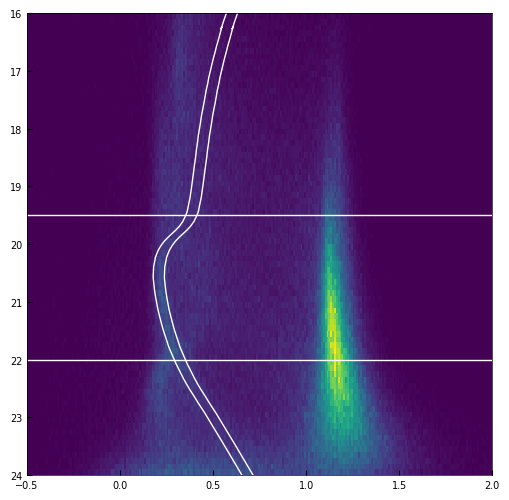

In [288]:
fig, ax0 = plt.subplots(1, 1, figsize=(6,6), sharex=False, sharey=False)

plt.hist2d(data['g0mag']-data['r0mag'], data['r0mag'], bins=(np.arange(-0.5,2.01,0.01), np.arange(16,24.1,0.1)))#, norm=mpl.colors.LogNorm())

idx = 1
mask = old_iso_cfht[idx]['label'] <= 3
x = old_iso_cfht[idx]["g'mag"][mask]-old_iso_cfht[idx]["r'mag"][mask]
y = old_iso_cfht[idx]["r'mag"][mask]+16.6
plt.plot(x+0.03, y, c='w')
plt.plot(x-0.03, y, c='w')

interp = interp1d(y, x, bounds_error=False, fill_value=999)

plt.hlines([19.5, 22], -0.5, 2.0, color='w')

mask = (data['g0mag']-data['r0mag'] > interp(data['r0mag'])-0.03)
mask &= (data['g0mag']-data['r0mag'] < interp(data['r0mag'])+0.03)
mask &= (data['r0mag'] < 22)
mask &= (data['r0mag'] > 19.5)
data_cfht = coord.SkyCoord(data['RAJ2000'][mask], data['DEJ2000'][mask], frame='icrs', unit=(u.hourangle, u.deg))

mask2 = (data['g0mag']-data['r0mag'] > interp(data['r0mag'])+0.03)
mask2 &= (data['g0mag']-data['r0mag'] < interp(data['r0mag'])+0.09)
mask2 &= (data['r0mag'] < 22)
mask2 &= (data['r0mag'] > 19.5)
data2_cfht = coord.SkyCoord(data['RAJ2000'][mask2], data['DEJ2000'][mask2], frame='icrs', unit=(u.hourangle, u.deg))

# mask = old_iso_cfht[3]['label'] < 3
# plt.plot(old_iso_cfht[3]["g'mag"][mask]-old_iso_cfht[3]["r'mag"][mask], old_iso_cfht[3]["r'mag"][mask]+16.5)

plt.ylim(24,16)
plt.show()

8945
6627


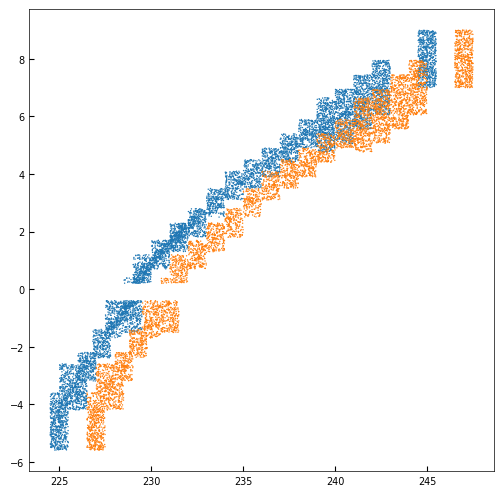

In [266]:
fig, ax0 = plt.subplots(1, 1, figsize=(6,6), sharex=False, sharey=False)

ra = data_cfht.ra.to_value('deg')
dec = data_cfht.dec.to_value('deg')
# plt.hist2d(ra[dec>0.2], dec[dec>0.2], bins=50)#, norm=mpl.colors.LogNorm())
# plt.hist2d(ra[dec<-0.4], dec[dec<-0.4], bins=50)#, norm=mpl.colors.LogNorm())

plt.scatter(ra[(dec>0.2)|(dec<-0.4)], dec[(dec>0.2)|(dec<-0.4)], ec='none', s=1)
print(len(ra[(dec>0.2)|(dec<-0.4)]))
# plt.scatter(ra[dec<-0.4], dec[dec<-0.4], ec='none', s=1)

ra2 = data2_cfht.ra.to_value('deg')
dec2 = data2_cfht.dec.to_value('deg')
plt.scatter(ra2[(dec2>0.2)|(dec2<-0.4)]+2, dec2[(dec2>0.2)|(dec2<-0.4)], ec='none', s=1)
print(len(ra2[(dec2>0.2)|(dec2<-0.4)]))

plt.show()

In [268]:
(8945 - 6627) / 8945

0.259139183901621

In [243]:
append_data = np.full(len(ra), fill_value=np.nan, dtype = {
    'names':   ('star_id', 'ra', 'dec', 'plx', 'mu_ra', 'mu_dec', 'G',  'BP-RP', 'vr', 'evr', 'rvr', 'stream_id'),
    'formats': ('i8',      'f8', 'f8',  'f8',  'f8',    'f8',     'f8', 'f8',    'f8', 'f8',  'i8' , 'i8'       )})

append_data['ra'] = ra
append_data['dec'] = dec
append_data['BP-RP'] = data['g0mag'][mask]-data['r0mag'][mask]
append_data['G'] = data['r0mag'][mask]
append_data['stream_id'] = 999

newd = np.r_[d, append_data]

## Load GCs

In [14]:
# load MW metal and mass

mass_mw = []
name_mass_mw = []
feh_mw = []
name_feh_mw = []
f_mw = '../data/combined_table_mass.txt'
with open(f_mw, 'rb') as reader:
    lines = reader.readlines()[2:160]
    for line in lines:
        mass_mw.append(np.log10(float(line[65:76])))
        name_mass_mw.append(str(line[0:13].strip())[2:-1].replace(' ', '_'))
f_mw = '../data/mwgc.dat'
with open(f_mw, 'rb') as reader:
    lines = reader.readlines()[252:409]
    for line in lines:
        fehh = str(line[13:19].strip())[2:-1]
        if len(fehh) == 0:
            continue
        feh_mw.append(float(fehh))
        name_feh_mw.append(str(line[1:13].strip())[2:-1].replace(' ', '_'))
mass_mw = np.array(mass_mw)
name_mass_mw = np.array(name_mass_mw)
feh_mw = np.array(feh_mw)
name_feh_mw = np.array(name_feh_mw)

xy, idx1, idx2 = np.intersect1d(name_feh_mw, name_mass_mw, return_indices=True)

# load mw pos and vel

dtype5 = {
    'names': (
        'Cluster', 'RA', 'DEC', 'l', 'b', 'Rsun', 'ERsun', 'R_GC', '<RV>', 'ERV',
        'mu_alpha', 'Dmu_alpha', 'mu_delta', 'Dmu_delta', 'rhopmrade', 'X', 'DX', 
        'Y', 'DY', 'Z', 'DZ', 'U', 'DU', 'V', 'DV', 'W', 'DW', 'RPERI', 'DRPERI', 'RAPO', 'DRAPO'),
    'formats': (
        'U16', 'f8', 'f8', 'f8', 'f8', 'f8', 'f8', 'f8', 'f8', 'f8', 
        'f8', 'f8', 'f8', 'f8', 'f8', 'f8', 'f8', 'f8', 'f8', 'f8',
        'f8', 'f8', 'f8', 'f8', 'f8', 'f8', 'f8', 'f8', 'f8', 'f8', 'f8', 'f8')}
path = '../data/orbits_table_v4.txt'
data_mw = np.loadtxt(path, dtype=dtype5)

x_mw = data_mw['X']
y_mw = data_mw['Y']
z_mw = data_mw['Z']
vx_mw = data_mw['U']
vy_mw = data_mw['V']
vz_mw = data_mw['W']

logr_mw = np.log10(np.sqrt(x_mw**2 + y_mw**2))
logr3d_mw = np.log10(np.sqrt(x_mw**2 + y_mw**2 + z_mw**2))
r_mw = np.sqrt(x_mw**2 + y_mw**2 + z_mw**2)
name_rho_mw = data_mw['Cluster']

l_wrap_at_180 = np.copy(data_mw['l'])
l_wrap_at_180[data_mw['l']>180] -= 360

ra_wrap_at_180 = np.copy(data_mw['RA'])
ra_wrap_at_180[data_mw['RA']>180] -= 360

# load structure

dtype0 = {
    'names': (
        'Cluster', 'RA', 'DEC', 'R_Sun', 'DR_Sun', 'R_GC', 'DR_GC', 'N_RV', 'N_PM', 'Mass', 'DM',
        'V', 'DV', 'M/L_V', 'DM/L', 'rc', 'rh,l', 'rh,m', 'rt', 'rho_c', 'rho_h,m', 'sig_c', 
        'sig_h,m', 'lg Trh', 'lg Mini',  'T_Diss', 'M_Low', 'M_High', 'MF', 'symbol', 'DMF', 
        'sig0', 'vesc', 'etac', 'etah'),
    'formats': (
        'U16', 'f8', 'f8', 'f8', 'f8', 'f8', 'f8', 'f8', 'f8', 'f8', 'f8',
        'f8', 'f8', 'f8', 'f8', 'f8', 'f8', 'f8', 'f8', 'f8', 'f8', 'f8',
        'f8', 'f8', 'f8', 'f8', 'f8', 'f8', 'f8', 'U4', 'f8', 
        'f8', 'f8', 'f8', 'f8')}
path = '../data/combined_table.txt'
data_structure_mw = np.loadtxt(path, dtype=dtype0)

In [15]:
# Ibata+21
gc_stream_list = ['NGC_288', 'NGC_1261', 'NGC_1851', 'NGC_2298', 'NGC_2808', 'NGC_3201', 'NGC_4590', 'NGC_5139', 'NGC_5466', 'Pal_5',
'NGC_5904', 'NGC_6101', 'NGC_6341', 'NGC_6397', 'NGC_7089']
gc_stream_list = ['NGC_3201', 'NGC_4590', 'NGC_5139', 'Pal_5', 'NGC_6341', 'NGC_6397']
gc_stream_ids = np.array([9, 32, 16, 19, 24, 26], dtype=int)
gc_stream_list = ['NGC_3201', 'NGC_4590', 'NGC_5139', 'Pal_5', 'NGC_6341', 'NGC_6397']
gc_stream_ids = np.array([6, 22, 16, 19, 24, 26], dtype=int)
# gc_stream_list = ['NGC_3201', 'NGC_4590', 'Pal_5', 'NGC_6341', 'NGC_6397'] # omega cen is too massive. exclude here.
# gc_stream_ids = np.array([6, 22, 19, 24, 26], dtype=int) # NGC_3201 can be either 6 or 9; NGC 4590 can be either 22 or 32
gc_stream_list, idx_with_stream, idx_with_stream_stream = np.intersect1d(data_mw['Cluster'], gc_stream_list, return_indices=True)
gc_stream_ids = gc_stream_ids[idx_with_stream_stream]

In [244]:
# Ibata+24

gc_stream_list = ['NGC_3201', 'NGC_4590', 'NGC_5139', 'Pal_5', 'NGC_6341', 'NGC_6397',
    'NGC_288', 'NGC_1261', 'NGC_1851', 'NGC_2298', 'NGC_2808', 'NGC_5466', 'NGC_5904', 'NGC_6101', 'NGC_7089']
gc_stream_ids = np.array([34, 47, 54, 61, 68, 69,
    3, 12, 16, 23, 26, 57, 62, 67, 76], dtype=int)
gc_stream_list = ['NGC_3201', 'NGC_4590', 'NGC_5139', 'Pal_5', 'NGC_6341', 'NGC_6397',
    'NGC_288', 'NGC_1851', 'NGC_2298', 'NGC_2808', 'NGC_5904', 'NGC_6101'] # remove 7089: too few stars; remove 1261, 5466, 7099: can't fit
gc_stream_ids = np.array([34, 47, 54, 61, 68, 69,
    3, 16, 23, 26, 62, 67], dtype=int)
gc_stream_ids = np.array([34, 47, 54, 999, 68, 69,
    3, 16, 23, 26, 62, 67], dtype=int)
gc_stream_list, idx_with_stream, idx_with_stream_stream = np.intersect1d(data_mw['Cluster'], gc_stream_list, return_indices=True)
gc_stream_ids = gc_stream_ids[idx_with_stream_stream]

In [17]:
def display_name_convert(name):
    return (name
        .replace('_', ' ')
        .replace('NGC 4590', 'M68')
        .replace('NGC 5139', r'$\omega$Cen')
        .replace('NGC 6341', 'M92')
        .replace('NGC 5904', 'M5')
        )
    
def display_name_simple_convert(name):
    return (name
        .replace('_', ' ')
        .replace('NGC 4590', 'M68')
        .replace('NGC 5139', r'$\omega$Cen')
        .replace('NGC 6341', 'M92')
        .replace('NGC 5904', 'M5')
        .replace('NGC ', 'N')
        )

In [18]:
%%script true
# Ibata+21 only

cs = ['k', 'r', 'b', 'g', 'm', 'orange'] * 3
for i in range(len(gc_stream_ids)):
    mask = d['stream_id'] == gc_stream_ids[i]
    plt.scatter(l[mask].wrap_at(180*u.deg), b[mask], c=cs[i], s=1)
    plt.scatter(l_wrap_at_180[idx_with_stream][i],data_mw['b'][idx_with_stream][i], fc=cs[i], ec='w', lw=2, label=gc_stream_list[i])

plt.xlabel(r'$l\ (^\circ)$')
plt.ylabel(r'$b\ (^\circ)$')
plt.xlim(100,-180)
plt.ylim(-45,90)
plt.legend(loc='lower left', frameon=False)
plt.gca().set_aspect(1)
plt.show()

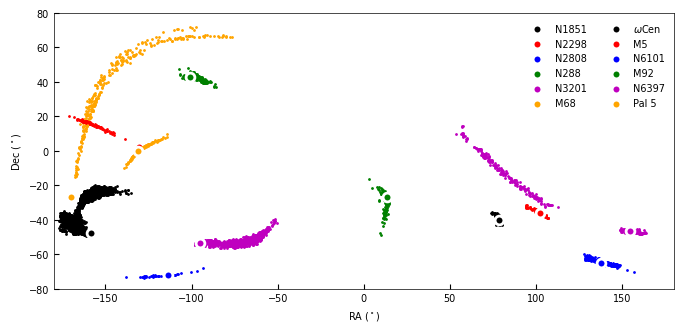

In [19]:

fig, ax0 = plt.subplots(1, 1, figsize=(8,4), sharex=False, sharey=False)

cs = ['k', 'r', 'b', 'g', 'm', 'orange'] * 3
for i in range(len(gc_stream_ids)):
    mask = d['stream_id'] == gc_stream_ids[i]
    x = np.copy(d['ra'])
    x[d['ra']>180] -= 360
    plt.scatter(x[mask], d['dec'][mask], c=cs[i], s=1)
    plt.scatter(ra_wrap_at_180[idx_with_stream][i],data_mw['DEC'][idx_with_stream][i], fc=cs[i], ec='w', lw=2, s=40, label=display_name_simple_convert(gc_stream_list[i]))

plt.xlabel(r'RA $(^\circ)$')
plt.ylabel(r'Dec $(^\circ)$')
plt.xlim(-180,180)
plt.ylim(-80,80)
plt.legend(loc='upper right', frameon=False, ncol=2)
plt.gca().set_aspect(1)
plt.show()

### Fit streams with gala or agama

In [20]:
pot = gp.BovyMWPotential2014(units=galactic)
# pot = gp.MilkyWayPotential2022(units=galactic)
H = gp.Hamiltonian(pot)

pot_agama = agama.Potential("../data/MWPotential2014.ini")

NGC_1851 GC mass = 2.81e+05 Msun, Rperi = 0.90 kpc, Rapo = 19.90 kpc
NGC_2298 GC mass = 5.72e+04 Msun, Rperi = 0.97 kpc, Rapo = 16.49 kpc
NGC_2808 GC mass = 8.69e+05 Msun, Rperi = 1.08 kpc, Rapo = 14.60 kpc
NGC_288 GC mass = 9.84e+04 Msun, Rperi = 1.93 kpc, Rapo = 12.34 kpc
NGC_3201 GC mass = 1.41e+05 Msun, Rperi = 8.34 kpc, Rapo = 25.52 kpc
NGC_4590 GC mass = 1.32e+05 Msun, Rperi = 8.88 kpc, Rapo = 29.37 kpc
NGC_5139 GC mass = 3.34e+06 Msun, Rperi = 1.47 kpc, Rapo = 6.95 kpc
NGC_5904 GC mass = 3.68e+05 Msun, Rperi = 3.25 kpc, Rapo = 23.44 kpc
NGC_6101 GC mass = 1.30e+05 Msun, Rperi = 10.19 kpc, Rapo = 35.74 kpc
NGC_6341 GC mass = 3.12e+05 Msun, Rperi = 1.25 kpc, Rapo = 10.62 kpc
NGC_6397 GC mass = 8.98e+04 Msun, Rperi = 2.60 kpc, Rapo = 6.30 kpc
Pal_5 GC mass = 1.71e+04 Msun, Rperi = 8.88 kpc, Rapo = 17.54 kpc


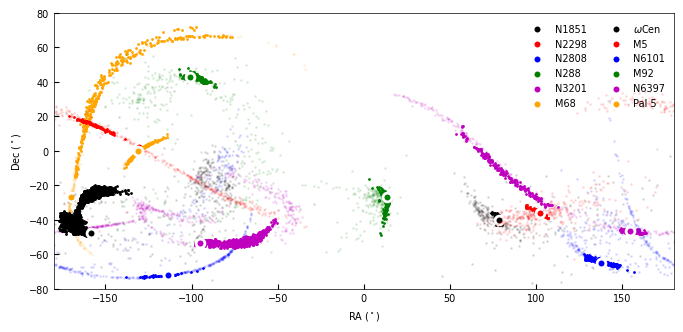

In [21]:
frame = 'ICRS'
t_tot = 2000 * u.Myr
dt = 10 * u.Myr

fig, ax0 = plt.subplots(1, 1, figsize=(8,4), sharex=False, sharey=False)

for i in range(len(gc_stream_ids)):
    mask = d['stream_id'] == gc_stream_ids[i]
    if frame == 'ICRS':
        x = np.copy(d['ra'])
        x[d['ra']>180] -= 360
        plt.scatter(x[mask], d['dec'][mask], c=cs[i], s=1)
    elif frame == 'Galactic':
        plt.scatter(l[mask].wrap_at(180*u.deg), b[mask], c=cs[i], s=1)

    c = coord.ICRS(ra=data_mw['RA'][idx_with_stream][i] * u.deg, dec=data_mw['DEC'][idx_with_stream][i] * u.deg,
        distance=data_mw['Rsun'][idx_with_stream][i] * u.kpc,
        pm_ra_cosdec=data_mw['mu_alpha'][idx_with_stream][i] * u.mas/u.yr,
        pm_dec=data_mw['mu_delta'][idx_with_stream][i] * u.mas/u.yr,
        radial_velocity=data_mw['<RV>'][idx_with_stream][i] * u.km/u.s)
    
    # c = coord.Galactocentric(
    #     x=-data_mw['X'][idx_with_stream][i] * u.kpc, 
    #     y=-data_mw['Y'][idx_with_stream][i] * u.kpc,
    #     z=data_mw['X'][idx_with_stream][i] * u.kpc,
    #     v_x=-data_mw['U'][idx_with_stream][i] * u.km/u.s,
    #     v_y=-data_mw['V'][idx_with_stream][i] * u.km/u.s,
    #     v_z=data_mw['W'][idx_with_stream][i] * u.km/u.s)
    
    # gala
    c_gc = c.transform_to(coord.Galactocentric()).cartesian
    gc_w0 = gd.PhaseSpacePosition(c_gc)
    gc_mass = 10**mass_mw[np.where(name_mass_mw == gc_stream_list[i])[0][0]] * u.Msun
    print('%s GC mass = %.2e Msun, Rperi = %.2f kpc, Rapo = %.2f kpc'%(
        gc_stream_list[i], gc_mass.value, data_mw['RPERI'][idx_with_stream][i], data_mw['RAPO'][idx_with_stream][i]))
    gc_pot = gp.PlummerPotential(m=gc_mass, b=4*u.pc, units=galactic)

    df = ms.ChenStreamDF()
    gen = ms.MockStreamGenerator(df, pot, progenitor_potential=gc_pot)
    stream, _ = gen.run(gc_w0, gc_mass, dt=-dt, n_steps=int(t_tot/dt))

    # agama
    # c_gc = c.transform_to(coord.Galactocentric()).cartesian
    # gc_w0 = gd.PhaseSpacePosition(c_gc)
    # gc_mass = 10**mass_mw[np.where(name_mass_mw == gc_stream_list[i])[0][0]]
    # gc_pot = agama.Potential(type='Plummer', mass=gc_mass, scaleRadius=4e-3)
    # gc_posvel = np.r_[gc_w0.xyz.to('kpc').value, gc_w0.v_xyz.to('km/s').value]
    # time_sat, orbit_sat, xv_stream, ic_stream, time_stream = \
    #     create_stream(create_ic_chen24, np.random.default_rng(0), -t_tot.to('0.978*Gyr').value, 2*int(t_tot/dt), pot_agama, gc_posvel, gc_mass, pot_sat=gc_pot)
    # stream = gd.MockStream(
    #     pos=xv_stream[:,0:3].T*u.kpc,
    #     vel=xv_stream[:,3:6].T*u.km/u.s,
    #     release_time=time_stream*0.978*u.Gyr
    # )
    
    if frame == 'ICRS':
        stream_c = stream.to_coord_frame(coord.ICRS())
        plt.scatter(stream_c.ra.wrap_at(180*u.deg), stream_c.dec, s=1, alpha=0.1, fc=cs[i])
        plt.scatter(ra_wrap_at_180[idx_with_stream][i],data_mw['DEC'][idx_with_stream][i], 
            fc=cs[i], ec='w', lw=2, s=40, label=display_name_simple_convert(gc_stream_list[i]))
    elif frame == 'Galactic':
        stream_c = stream.to_coord_frame(coord.Galactic())
        plt.scatter(stream_c.l.wrap_at(180*u.deg), stream_c.b, s=1, alpha=0.1, fc=cs[i])
        plt.scatter(l_wrap_at_180[idx_with_stream][i],data_mw['b'][idx_with_stream][i], 
            fc=cs[i], ec='w', lw=2, s=40, label=display_name_simple_convert(gc_stream_list[i]))
    
if frame == 'ICRS':
    plt.xlabel(r'RA $(^\circ)$')
    plt.ylabel(r'Dec $(^\circ)$')
    plt.xlim(-180,180)
    plt.ylim(-80,80)
elif frame == 'Galactic':
    plt.xlabel(r'$l\ (^\circ)$')
    plt.ylabel(r'$b\ (^\circ)$')
    plt.xlim(100,-180)
    plt.ylim(-45,90)

plt.legend(frameon=False, ncol=2, loc='upper right')
plt.gca().set_aspect(1)
plt.show()

### construct great circle system

In [22]:
def rotate1(angles, ra, dec):
    alpha = angles[0]
    beta = angles[1]
    mat = rotation_matrix(beta*u.deg, 'x') @ rotation_matrix(alpha*u.deg, 'z')
    x = np.cos(dec) * np.cos(ra)
    y = np.cos(dec) * np.sin(ra)
    z = np.sin(dec)

    pos = np.row_stack((x,y,z))
    pos_new = mat @ pos
    x = pos_new[0]
    y = pos_new[1]
    z = pos_new[2]

    phi1 = np.arctan2(y, x)
    phi2 = np.arcsin(z)

    return np.mean(phi2**2)

def rotate2(angles, alpha, beta, ra, dec):
    gamma = angles[0]
    mat = rotation_matrix(gamma*u.deg, 'z') @ rotation_matrix(beta*u.deg, 'x') @ rotation_matrix(alpha*u.deg, 'z')
    x = np.cos(dec) * np.cos(ra)
    y = np.cos(dec) * np.sin(ra)
    z = np.sin(dec)

    pos = np.row_stack((x,y,z))
    pos_new = mat @ pos
    x = pos_new[0]
    y = pos_new[1]
    z = pos_new[2]

    phi1 = np.arctan2(y, x)
    phi2 = np.arcsin(z)

    return np.mean(phi1**2)

G_limit = 19

alpha_stream_list = np.full(len(gc_stream_ids), fill_value=np.nan)
beta_stream_list = np.full(len(gc_stream_ids), fill_value=np.nan)
gamma_stream_list = np.full(len(gc_stream_ids), fill_value=np.nan)
mat_stream_list = np.full((len(gc_stream_ids),3,3), fill_value=np.nan)

for i in range(len(gc_stream_ids)):
    mask = (d['stream_id'] == gc_stream_ids[i]) & (d['G']<=G_limit)
    # stream_obs_c = coord.ICRS(ra=d['ra'][mask]*u.deg, dec=d['dec'][mask]*u.deg)

    ra = d['ra'][mask]*np.pi/180 # in rad
    dec = d['dec'][mask]*np.pi/180 # in rad

    record = np.inf
    for guess1 in range(-180,181,30):
        for guess2 in range(-180,181,30):
            o = minimize(rotate1, (guess1,guess2), args=(ra, dec))
            if o.fun < record:
                alpha = o.x[0]
                beta = o.x[1]
                record = o.fun
    # print(np.sqrt(record)*180/np.pi)
    o = minimize(rotate2, (0), args=(alpha, beta, ra, dec))
    # print(np.sqrt(o.fun)*180/np.pi)
    gamma = o.x[0]
    # print(alpha, beta, gamma)
    mat = rotation_matrix(gamma*u.deg, 'z') @ rotation_matrix(beta*u.deg, 'x') @ rotation_matrix(alpha*u.deg, 'z')

    alpha_stream_list[i] = alpha
    beta_stream_list[i] = beta
    gamma_stream_list[i] = gamma
    mat_stream_list[i] = mat

In [23]:
# IC for progenitor

c_list = []
for i in range(len(gc_stream_ids)):
    if gc_stream_list[i] == 'Pal_5':
        # use Koposov+17 values
        c = coord.ICRS(
            ra=229 * u.deg, 
            dec=-0.111 * u.deg,
            distance=23.6 * u.kpc,
            pm_ra_cosdec=-2.23 * u.mas/u.yr,
            pm_dec=-2.22 * u.mas/u.yr,
            radial_velocity=-57.4 * u.km/u.s)
    else:
        # use GC catalog values
        c = coord.ICRS(
            ra=data_mw['RA'][idx_with_stream][i] * u.deg, 
            dec=data_mw['DEC'][idx_with_stream][i] * u.deg,
            distance=data_mw['Rsun'][idx_with_stream][i] * u.kpc,
            pm_ra_cosdec=data_mw['mu_alpha'][idx_with_stream][i] * u.mas/u.yr,
            pm_dec=data_mw['mu_delta'][idx_with_stream][i] * u.mas/u.yr,
            radial_velocity=data_mw['<RV>'][idx_with_stream][i] * u.km/u.s)
        
    c_list.append(c)

In [24]:
from scipy.signal import find_peaks

def get_peri_apo(x,y,z):
    r2 = x**2 + y**2 + z**2
    median = np.median(r2)
    peaks_apo, _ = find_peaks(r2, height=median)
    peaks_peri, _ = find_peaks(-r2, height=-median)

    return peaks_apo, peaks_peri

In [25]:
def f84(x):
    return np.percentile(x, 84)
def f16(x):
    return np.percentile(x, 16)

Pal_5 Pal 5 GC mass = 1.71e+04 Msun, Rperi = 8.88 kpc, Rapo = 17.54 kpc
3998 orbits complete (1.01e+04 orbits/s)
width in pc = 168.99155101313832
mass loss rates = [31.70383258 28.82614997]
mass loss rate = 9.364 Msun/Myr
mass loss rate / mass = 5.476e-04 1/Myr
rh / rt = 0.556



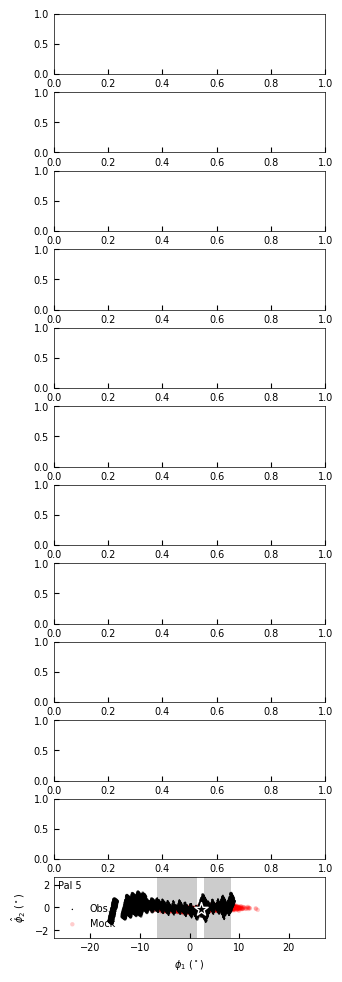

In [285]:
G_limit = 19
t_tot = 2000 * u.Myr
dt = 1 * u.Myr
n_steps = int(t_tot/dt)

center_on_poly = True

uniform = True
Tfrac = 0.05
N = 1000

if uniform:
    N = 2*n_steps

f_rtid = 1
f_width = 6

n_obs_list = []
rate_list = []
mgc_list = []
ratio_list = []
T_list = []

# for age plot
length_list = []
width_list = []
ranges_list = []
x_age_list = []
y16_age_list = []
y84_age_list = []

class GreatCircle(coord.BaseCoordinateFrame):
    default_representation = coord.SphericalRepresentation
    default_differential = coord.SphericalCosLatDifferential

    frame_specific_representation_info = {
        coord.SphericalRepresentation: [
            coord.RepresentationMapping('lon', 'phi1'),
            coord.RepresentationMapping('lat', 'phi2'),
            coord.RepresentationMapping('distance', 'distance'),
        ]
    }

fig, axs = plt.subplots(len(gc_stream_ids), 1, figsize=(3.5,12), sharex=False, sharey=False)

# for i in range(len(gc_stream_ids)):
for i in [-1]:
    ax = axs[i]
    c = c_list[i]

    if gc_stream_ids[i] == 999:
        G_limit = 22
    else:
        G_limit = 19
    
    ax.text(0.015, 0.94, display_name_convert(gc_stream_list[i]), 
        va='top', ha='left', transform=ax.transAxes)
    
    c_gc = c.transform_to(coord.Galactocentric()).cartesian
    gc_w0 = gd.PhaseSpacePosition(c_gc)
    gc_mass = 10**mass_mw[np.where(name_mass_mw == gc_stream_list[i])[0][0]] * u.Msun
    print('%s %s GC mass = %.2e Msun, Rperi = %.2f kpc, Rapo = %.2f kpc'%(
        gc_stream_list[i], display_name_convert(gc_stream_list[i]), 
        gc_mass.value, data_mw['RPERI'][idx_with_stream][i], data_mw['RAPO'][idx_with_stream][i]))
    gc_pot = gp.PlummerPotential(m=gc_mass, b=4*u.pc, units=galactic)

    df = ms.ChenStreamDF(random_state=np.random.RandomState(0))
    gen = ms.MockStreamGenerator(df, pot, progenitor_potential=gc_pot)
    if uniform:
        # stream, _ = gen.run(gc_w0, gc_mass, dt=-dt, n_steps=n_steps)

        # agama
        gc_pot = agama.Potential(type='Plummer', mass=gc_mass.to('Msun').value, scaleRadius=4e-3)
        gc_posvel = np.r_[gc_w0.xyz.to('kpc').value, gc_w0.v_xyz.to('km/s').value]
        time_sat, orbit_sat, xv_stream, ic_stream, time_stream = \
            create_stream(create_ic_chen24, np.random.default_rng(0), -t_tot.to('0.978*Gyr').value, 2*int(t_tot/dt), 
                pot_agama, gc_posvel, gc_mass.to('Msun').value, pot_sat=gc_pot)
        stream = gd.MockStream(
            pos=xv_stream[:,0:3].T*u.kpc,
            vel=xv_stream[:,3:6].T*u.km/u.s,
            release_time=time_stream*0.978*u.Gyr
        )
    else:
        orbit = pot.integrate_orbit(gc_w0, dt=-dt, n_steps=n_steps)
        
        pos = orbit.pos.xyz.value.T
        vel = orbit.vel.d_xyz.to('km/s').value.T

        r = np.sqrt(pos[:,0]**2 + pos[:,1]**2 + pos[:,2]**2)
        print('integrated orbit: Rperi = %.2f kpc, Rapo = %.2f kpc'%(np.min(r), np.max(r)))
        
        apos, peris = get_peri_apo(pos[:,0], pos[:,1], pos[:,2])
        T = np.mean(peris[1:] - peris[:-1])
        T_list.append(T*dt.value)
        Tsig = Tfrac * T
        rate = np.zeros(n_steps+1)
        for peri in peris:
            t_to_peri2 = (np.arange(n_steps+1) - peri)**2
            rate += 0.398942/Tsig*np.exp(-0.5*t_to_peri2/Tsig**2)/len(peris)
        
        rate = np.round(rate*N/np.sum(rate)).astype(int)
        
        stream, _ = gen.run(gc_w0, gc_mass, dt=-dt, n_steps=n_steps, n_particles=rate[::-1])
    
    stream_c = stream.to_coord_frame(coord.ICRS())

    @frame_transform_graph.transform(coord.StaticMatrixTransform, coord.ICRS, GreatCircle)
    def icrs_to_GreatCircle():
        return mat_stream_list[i]
    
    @frame_transform_graph.transform(coord.StaticMatrixTransform, GreatCircle, coord.ICRS)
    def GreatCircle_to_icrs():
        return matrix_transpose(mat_stream_list[i])
    
    stream_GreatCircle = stream_c.transform_to(GreatCircle())
    c_GreatCircle = c.transform_to(GreatCircle())

    idx_structure = np.where(data_structure_mw['Cluster'] == gc_stream_list[i])[0]
    assert len(idx_structure) == 1
    rtid = data_structure_mw['rt'][idx_structure[0]]
    angle_rtid = (rtid / c_GreatCircle.distance.to('pc').value)*180/np.pi

    if gc_stream_ids[i] == 999:
        mask = (newd['stream_id'] == gc_stream_ids[i]) & (newd['G']<=G_limit)
        stream_obs_c = coord.ICRS(ra=newd['ra'][mask]*u.deg, dec=newd['dec'][mask]*u.deg)
    else:
        mask = (d['stream_id'] == gc_stream_ids[i]) & (d['G']<=G_limit)
        stream_obs_c = coord.ICRS(ra=d['ra'][mask]*u.deg, dec=d['dec'][mask]*u.deg)
    stream_obs_GreatCircle = stream_obs_c.transform_to(GreatCircle())

    phi1_obs = stream_obs_GreatCircle.phi1.wrap_at(180*u.deg).value
    phi2_obs = stream_obs_GreatCircle.phi2.value

    p = np.polyfit(phi1_obs, phi2_obs, deg=2)
    x = np.arange(-100,100,1)
    fit_poly = np.poly1d(p)
    width = np.sqrt(np.mean((phi2_obs-fit_poly(phi1_obs))**2))

    # plot the progenitor GC
    phi1_gc = c_GreatCircle.phi1.wrap_at(180*u.deg).value
    phi2_gc  = c_GreatCircle.phi2.value
    if center_on_poly:
        ax.scatter(phi1_gc, phi2_gc-fit_poly(phi1_gc), s=100, marker='*', fc='k', ec='w', lw=1, zorder=100)
    else:
        ax.scatter(phi1_gc, phi2_gc, s=100, marker='*', fc='k', ec='w', lw=1, zorder=100)
    
    mask_left = (phi1_obs<phi1_gc-f_rtid*angle_rtid) & (phi2_obs-fit_poly(phi1_obs)>-f_width*width) & (phi2_obs-fit_poly(phi1_obs)<f_width*width)
    mask_right = (phi1_obs>phi1_gc+f_rtid*angle_rtid) & (phi2_obs-fit_poly(phi1_obs)>-f_width*width) & (phi2_obs-fit_poly(phi1_obs)<f_width*width)
    if gc_stream_ids[i] == 999:
        mask_left &= (phi1_obs>phi1_gc-10)
        mask_right &= (phi1_obs<phi1_gc+10)
    mask_lr = np.zeros_like(mask_left, dtype=bool)

    ranges = []
    masks = []
    if len(phi1_obs[mask_left]) >= 10:
        r = np.percentile(phi1_obs[mask_left], [10,90])
        ranges.append(r)
        mask_lr |= (mask_left & (phi1_obs>r[0]) & (phi1_obs<r[1]))
        masks.append((mask_left & (phi1_obs>r[0]) & (phi1_obs<r[1])))
    if len(phi1_obs[mask_right]) >= 10:
        r = np.percentile(phi1_obs[mask_right], [10,90])
        ranges.append(r)
        mask_lr |= (mask_right & (phi1_obs>r[0]) & (phi1_obs<r[1]))
        masks.append((mask_right & (phi1_obs>r[0]) & (phi1_obs<r[1])))
    # special treatment with omega cen, its GC is off center
    if gc_stream_list[i] == 'NGC_5139':
        r = np.percentile(phi1_obs, [10,90])
        ranges = [r]
        mask_lr = (phi2_obs-fit_poly(phi1_obs)>-f_width*width) & (phi2_obs-fit_poly(phi1_obs)<f_width*width) &  (phi1_obs>r[0]) & (phi1_obs<r[1])
        masks = [mask_lr]
    # special treatment with 3201, it has 3 segments
    if gc_stream_list[i] == 'NGC_3201':
        if np.max(np.abs(phi1_obs[mask_left])) < np.max(np.abs(phi1_obs[mask_right])):
            mask_short = mask_left
            mask_long = mask_right
        else:
            mask_short = mask_right
            mask_long = mask_left
        r = np.percentile(phi1_obs[mask_short], [10,90])
        ranges = [r]
        mask_long1 = mask_long & (phi1_obs<0)
        r = np.percentile(phi1_obs[mask_long1], [10,90])
        ranges.append(r)
        mask_long2 = mask_long & (phi1_obs>0)
        r = np.percentile(phi1_obs[mask_long2], [10,90])
        ranges.append(r)
        masks = [(mask_short & (phi1_obs>ranges[0][0]) & (phi1_obs<ranges[0][1])), 
            (mask_long1 & (phi1_obs>ranges[1][0]) & (phi1_obs<ranges[1][1])),
            (mask_long2 & (phi1_obs>ranges[2][0]) & (phi1_obs<ranges[2][1]))]
        mask_lr = ((mask_short & (phi1_obs>ranges[0][0]) & (phi1_obs<ranges[0][1])) | 
            (mask_long1 & (phi1_obs>ranges[1][0]) & (phi1_obs<ranges[1][1])) |
            (mask_long2 & (phi1_obs>ranges[2][0]) & (phi1_obs<ranges[2][1])))

    # if not center_on_poly:
    #     ax.plot(x, fit_poly(x), c='k', lw=2, alpha=0.6)

    # plot the obs. stars
    length = np.sqrt(np.mean(phi1_obs**2))
    if gc_stream_ids[i] == 999:
        sobs = 1
    else:
        sobs = 10
    if center_on_poly:
        ax.scatter(phi1_obs[~mask_lr], phi2_obs[~mask_lr]-fit_poly(phi1_obs[~mask_lr]), s=sobs, alpha=0.4, ec='k', fc='none', lw=1)
        ax.scatter(phi1_obs[mask_lr], phi2_obs[mask_lr]-fit_poly(phi1_obs[mask_lr]), s=sobs, alpha=1, ec='none', fc='k', label='Obs.')
        # ax.fill_between([-2*length, 2*length], [f_width*width, f_width*width], [-f_width*width, -f_width*width], ec='none', fc='k', alpha=0.2)
        for r in ranges:
            ax.fill_between(r, [f_width*width, f_width*width], [-f_width*width, -f_width*width], ec='none', fc='k', alpha=0.2)
    else:
        ax.scatter(phi1_obs[~mask_lr], phi2_obs[~mask_lr], s=sobs, alpha=0.4, ec='k', fc='none', lw=1)
        ax.scatter(phi1_obs[mask_lr], phi2_obs[mask_lr], s=sobs, alpha=1, ec='none', fc='k', label='Obs.')
        x = np.linspace(-2*length, 2*length,100)
        # ax.fill_between(x, fit_poly(x)+f_width*width, fit_poly(x)-f_width*width, ec='none', fc='k', alpha=0.2)
        for r in ranges:
            x = np.linspace(r[0], r[1],100)
            ax.fill_between(x, fit_poly(x)+f_width*width, fit_poly(x)-f_width*width, ec='none', fc='k', alpha=0.2)

    phi1_spray = stream_GreatCircle.phi1.wrap_at(180*u.deg).value
    phi2_spray = stream_GreatCircle.phi2.value
    # plot the mock stars
    if center_on_poly:
        ax.scatter(phi1_spray, phi2_spray-fit_poly(phi1_spray), s=10, alpha=0.2, fc='r', ec='none', label='Mock', zorder=0)
    else:
        ax.scatter(phi1_spray, phi2_spray, s=10, alpha=0.2, fc='r', ec='none', label='Mock', zorder=0)
    
    # compute the density for simulated streams
    num_in_range = 0
    length_in_range = 0
    density_spray_ranges = []
    for r in ranges:
        d_phi2 = phi2_spray-fit_poly(phi1_spray)
        width_spray = np.sqrt(np.mean((phi2_spray-fit_poly(phi1_spray))**2))
        weight = np.exp(-0.5*(d_phi2/width)**2) / np.exp(-0.5*(d_phi2/width_spray)**2)
        if gc_stream_ids[i] == 999:
            # flat selection function
            weight = np.ones_like(d_phi2)
        mask_in_range = (
            (phi1_spray>r[0]) & 
            (phi1_spray<=r[1]) & 
            (d_phi2>-f_width*width) & 
            (d_phi2<f_width*width)
        )
        # num_in_range += len(phi1_spray[mask_in_range])
        num_in_range += np.sum(weight[mask_in_range])
        length_in_range += r[1] - r[0]
        density_spray_ranges.append(np.sum(weight[mask_in_range])/(r[1]-r[0]))
    density_spray_ranges = np.array(density_spray_ranges)
    density_spray = num_in_range / length_in_range

    # directly get Gabs from Ibata distance
    # dist = d['d'][mask]
    # G_abs_here = G_abs[mask]
    
    # interp Gabs from fitted track. Needed for Ibata+24
    if gc_stream_ids[i] == 999:
        dist = np.full_like(newd['G'][mask], fill_value=data_mw['Rsun'][idx_with_stream][i])
        G_abs_here = newd['G'][mask] - 5*(np.log10(dist)+2)
    else:
        dist = np.full_like(d['G'][mask], fill_value=data_mw['Rsun'][idx_with_stream][i])
        G_abs_here = d['G'][mask] - 5*(np.log10(dist)+2)
    print('width in pc =', 1e3*data_mw['Rsun'][idx_with_stream][i]*width*np.pi/180)

    # compute the density of obs stream between phi1_l and phi1_h
    comp = np.inf
    idx = np.nan
    if gc_stream_ids[i] == 999:
        old_iso_here = old_iso_cfht
    else:
        old_iso_here = old_iso
    for j in range(len(old_iso_here)):
        iso = old_iso_here[j]
        if type(iso['label'][0]) == np.bytes_:
            iso_label = iso['label'][1:].astype(int)
            if gc_stream_ids[i] == 999:
                iso_G_BPmag = iso["g'mag"][1:].astype(float)
                iso_G_RPmag = iso["r'mag"][1:].astype(float)
                iso_Gmag = iso["r'mag"][1:].astype(float)
            else:
                iso_G_BPmag = iso['G_BPmag'][1:].astype(float)
                iso_G_RPmag = iso['G_RPmag'][1:].astype(float)
                iso_Gmag = iso['Gmag'][1:].astype(float)
        else:
            iso_label = iso['label']
            if gc_stream_ids[i] == 999:
                iso_G_BPmag = iso["g'mag"]
                iso_G_RPmag = iso["r'mag"]
                iso_Gmag = iso["r'mag"]
            else:
                iso_G_BPmag = iso['G_BPmag']
                iso_G_RPmag = iso['G_RPmag']
                iso_Gmag = iso['Gmag']
        mask1 = iso_label <= 3
        color = iso_G_BPmag[mask1][::-1]-iso_G_RPmag[mask1][::-1]
        Gmag = iso_Gmag[mask1][::-1]

        if gc_stream_ids[i] == 999:
            dcolor = newd['BP-RP'][mask] - np.interp(G_abs_here, Gmag, color)
        else:
            dcolor = d['BP-RP'][mask] - np.interp(G_abs_here, Gmag, color)
        dcolor = np.mean(dcolor**2)
        if dcolor < comp:
            comp = dcolor
            idx = j
    iso = old_iso_here[idx]
    if type(iso['label'][0]) == np.bytes_:
        iso_label = iso['label'][1:].astype(int)
        if gc_stream_ids[i] == 999:
            iso_G_BPmag = iso["g'mag"][1:].astype(float)
            iso_G_RPmag = iso["r'mag"][1:].astype(float)
            iso_Gmag = iso["r'mag"][1:].astype(float)
        else:
            iso_G_BPmag = iso['G_BPmag'][1:].astype(float)
            iso_G_RPmag = iso['G_RPmag'][1:].astype(float)
            iso_Gmag = iso['Gmag'][1:].astype(float)
        iso_Mini = iso['Mini'][1:].astype(float)
    else:
        iso_label = iso['label']
        if gc_stream_ids[i] == 999:
            iso_G_BPmag = iso["g'mag"]
            iso_G_RPmag = iso["r'mag"]
            iso_Gmag = iso["r'mag"]
        else:
            iso_G_BPmag = iso['G_BPmag']
            iso_G_RPmag = iso['G_RPmag']
            iso_Gmag = iso['Gmag']
        iso_Mini = iso['Mini']
    mask1 = iso_label <= 3
    color = iso_G_BPmag[mask1][::-1]-iso_G_RPmag[mask1][::-1]
    Gmag = iso_Gmag[mask1][::-1]
    Mini = iso_Mini[mask1][::-1]
    masses = np.interp(G_abs_here, Gmag, Mini)

    mass_limit = np.interp(G_limit - 5*(np.log10(dist)+2), Gmag, Mini)
    weight = kroupa(0, np.max(Mini)) / kroupa(mass_limit, np.max(Mini))

    mass_obs = np.sum(masses[mask_lr] * weight[mask_lr])
    if gc_stream_ids[i] == 999:
        masses_bg = np.interp(data['r0mag'][mask2] - 5*(np.log10(data_mw['Rsun'][idx_with_stream][i])+2), Gmag, Mini)
        frac = mass_obs / np.sum(masses)
        mass_obs -= np.sum(masses_bg)*frac
    density_obs_ranges = []
    for mask_seg, r in zip(masks,ranges):
        density_obs_ranges.append(np.sum(masses[mask_seg] * weight[mask_seg])/(r[1]-r[0]))
    density_obs = mass_obs / length_in_range
    density_obs_ranges = np.array(density_obs_ranges)
    n_obs_list.append(len(masses[mask_lr]))

    print('mass loss rates =', density_obs_ranges/density_spray_ranges*len(stream.x)/t_tot.value)
    print('mass loss rate = %.3f Msun/Myr'%(density_obs/density_spray*len(stream.x)/t_tot.value))
    print('mass loss rate / mass = %.3e 1/Myr'%(density_obs/density_spray*len(stream.x)/t_tot.value/gc_mass.value))
    rate_list.append(density_obs/density_spray*len(stream.x)/t_tot.value)
    mgc_list.append(gc_mass.value)

    idx_structure = np.where(data_structure_mw['Cluster'] == gc_stream_list[i])[0]
    assert len(idx_structure) == 1
    ratio = data_structure_mw['rh,m'][idx_structure[0]] / data_structure_mw['rt'][idx_structure[0]]
    print('rh / rt = %.3f'%ratio)
    ratio_list.append(ratio)

    if center_on_poly:
        ax.set_ylabel(r'$\hat{\phi}_2\ (^\circ)$')
    else:
        ax.set_ylabel(r'$\phi_2\ (^\circ)$')
    # ax.set_xlim(-20,20)
    # ax.set_ylim(-5,5)
    # if i == 0:
    #     ax.set_xlim(-100,20)
    #     ax.set_ylim(-20,20)
    # if i == 1:
    #     ax.set_xlim(-20,180)
    #     ax.set_ylim(-20,20)
    # if gc_stream_list[i] == 'NGC_5139':
    #     ax.set_xlim(-10,40)
    #     ax.set_ylim(-10,40)

    ax.set_xlim(-3.5*length,3.5*length)
    # if not center_on_poly:
    #     width = np.sqrt(np.mean(phi2_obs**2))
    if center_on_poly:
        ax.set_ylim(-f_width*width,f_width*width)
    else:
        ax.set_ylim(-10*width,10*width)
    # ax.legend(loc='upper left', frameon=False)
    print('')

    # collect data for age plot
    length_list.append(length)
    width_list.append(width)
    ranges_list.append(ranges)
    
    bins = np.linspace(np.min(ranges)-length,np.max(ranges)+length, 16+1)
    x_age = (bins[1:] + bins[:-1])/2
    mask_in_width = (phi2_spray-fit_poly(phi1_spray)>-f_width*width) & (phi2_spray-fit_poly(phi1_spray)<f_width*width)
    y16_age = binned_statistic(phi1_spray[mask_in_width], -stream.release_time[mask_in_width]/1e3, statistic=f16, bins=bins)[0]
    y84_age = binned_statistic(phi1_spray[mask_in_width], -stream.release_time[mask_in_width]/1e3, statistic=f84, bins=bins)[0]
    x_age_list.append(x_age)
    y16_age_list.append(y16_age)
    y84_age_list.append(y84_age)

ax.set_xlabel(r'$\phi_1\ (^\circ)$')
ax.legend(loc='lower left', frameon=False)
# plt.gca().set_aspect(1)
plt.subplots_adjust(hspace=0.3)
fig.align_ylabels(axs)
# plt.savefig('/Users/ybchen/Documents/GC-stream-mass-loss/figures/stream_fit.pdf', bbox_inches ='tight')
plt.show()

rate_short_list = np.array(rate_list)
mgc_short_list = np.array(mgc_list)
ratio_short_list = np.array(ratio_list)
T_short_list = np.array(T_list)
n_obs_short_list = np.array(n_obs_list)

# for age plot
length_short_list = np.array(length_list)
width_short_list = np.array(width_list)
x_age_short_list = np.array(x_age_list)
y16_age_short_list = np.array(y16_age_list)
y84_age_short_list = np.array(y84_age_list)

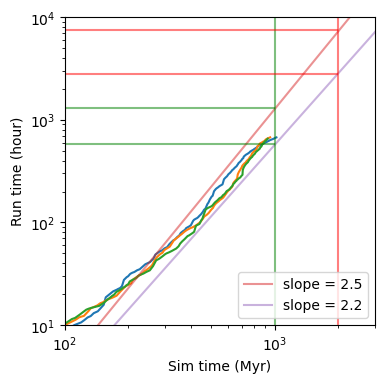

In [16]:
import matplotlib.pyplot as plt
import numpy as np

def fix_runtime(rt):
    runtime = np.copy(rt)
    for i in range(len(runtime)-1):
        if runtime[i+1] < runtime[i]:
            runtime[i+1:]+= rt[i]
    return runtime

fig, ax0 = plt.subplots(1, 1, figsize=(4,4), sharex=False, sharey=False)

step = [46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,255,256,257,258,]
t = [195.5,201.8,210.8,217.5,227.8,230.0,231.4,233.5,235.2,237.8,241.8,247.8,249.0,250.9,253.7,258.0,264.7,273.7,283.1,285.0,286.3,288.2,290.8,294.8,297.4,301.1,306.7,315.4,319.7,324.1,328.6,333.1,339.4,343.2,349.0,352.5,357.8,365.7,369.5,370.7,372.6,375.1,377.6,378.8,380.5,383.1,387.1,393.1,396.1,400.5,402.7,405.7,410.3,417.1,420.5,423.4,427.7,434.4,437.7,442.8,450.7,460.8,466.0,473.9,477.9,481.5,486.9,494.1,497.7,503.2,511.6,520.2,524.6,531.2,541.3,546.0,553.1,560.3,570.4,574.0,579.6,588.1,595.2,604.5,608.7,612.9,617.1,621.4,627.0,634.2,641.5,651.6,656.7,664.5,674.6,679.7,687.5,697.6,702.7,710.4,720.5,725.7,733.4,742.3,751.4,760.6,769.9,779.4,789.0,798.7,808.6,818.7,823.8,831.6,841.6,846.8,854.4,856.5,857.5,858.4,859.6,861.5,863.4,865.3,866.1,867.0,868.3,870.2,872.2,874.2,876.1,878.1,880.1,882.0,884.0,886.0,888.0,891.0,895.6,900.1,904.7,909.4,914.0,918.7,921.1,924.6,929.6,932.1,935.9,939.5,944.5,947.0,950.9,955.4,960.0,964.6,969.3,973.9,978.6,983.4,988.1,992.9,997.7,1002.6,1007.5,1012.4,1017.3,1022.3,1026.5,1030.7,1034.9,1039.1,1043.4,1047.7,1051.9,1056.3,1060.7,1065.0,1069.4,1073.8,1078.3,1082.8,1087.2,1091.8,1096.3,1100.9,1105.4,1110.1,1114.7,1119.4,1124.0,1127.9,1133.0,1135.5,1139.3,1144.3,1146.8,1150.6,1155.6,1158.2,1161.9,1166.5,1171.1,1175.7,1180.3,1184.9,1189.6,1194.3,1199.0,1203.8,1206.9,1211.7,1216.5,]
a = [0.0506,0.0517,0.0532,0.0543,0.0560,0.0564,0.0566,0.0569,0.0572,0.0576,0.0583,0.0592,0.0594,0.0597,0.0602,0.0608,0.0619,0.0633,0.0647,0.0650,0.0652,0.0655,0.0659,0.0665,0.0669,0.0674,0.0682,0.0695,0.0701,0.0708,0.0714,0.0721,0.0730,0.0735,0.0743,0.0748,0.0756,0.0767,0.0772,0.0774,0.0776,0.0780,0.0783,0.0785,0.0787,0.0791,0.0796,0.0805,0.0809,0.0815,0.0818,0.0822,0.0828,0.0837,0.0841,0.0845,0.0851,0.0860,0.0864,0.0871,0.0881,0.0894,0.0901,0.0911,0.0916,0.0921,0.0928,0.0937,0.0941,0.0948,0.0959,0.0969,0.0975,0.0983,0.0995,0.1001,0.1010,0.1019,0.1031,0.1035,0.1042,0.1052,0.1060,0.1071,0.1076,0.1081,0.1086,0.1091,0.1098,0.1106,0.1115,0.1126,0.1132,0.1141,0.1153,0.1158,0.1167,0.1178,0.1184,0.1193,0.1204,0.1210,0.1218,0.1228,0.1238,0.1248,0.1259,0.1269,0.1279,0.1290,0.1300,0.1311,0.1317,0.1325,0.1336,0.1341,0.1349,0.1351,0.1352,0.1353,0.1354,0.1356,0.1358,0.1360,0.1361,0.1362,0.1364,0.1366,0.1368,0.1370,0.1372,0.1374,0.1376,0.1378,0.1380,0.1382,0.1384,0.1387,0.1392,0.1397,0.1401,0.1406,0.1411,0.1416,0.1418,0.1422,0.1427,0.1430,0.1434,0.1437,0.1442,0.1445,0.1449,0.1453,0.1458,0.1463,0.1467,0.1472,0.1477,0.1482,0.1486,0.1491,0.1496,0.1501,0.1506,0.1511,0.1516,0.1520,0.1525,0.1529,0.1533,0.1537,0.1541,0.1545,0.1550,0.1554,0.1558,0.1563,0.1567,0.1571,0.1576,0.1580,0.1584,0.1589,0.1593,0.1597,0.1602,0.1606,0.1611,0.1615,0.1620,0.1624,0.1628,0.1631,0.1634,0.1639,0.1642,0.1645,0.1650,0.1652,0.1656,0.1660,0.1665,0.1669,0.1674,0.1678,0.1682,0.1687,0.1691,0.1696,0.1699,0.1703,0.1708,]
runtime_per_t = [0.013,0.093,0.040,0.052,0.027,0.033,0.054,0.045,0.054,0.035,0.071,0.117,0.092,0.073,0.057,0.043,0.060,0.162,0.083,0.147,0.120,0.081,0.157,0.096,0.117,0.332,0.109,0.071,0.131,0.150,0.084,0.179,0.087,0.219,0.222,0.827,0.197,0.199,0.114,0.141,0.107,0.145,0.101,0.140,0.207,0.290,0.896,0.292,0.182,0.354,0.199,0.159,0.114,0.196,0.122,0.123,0.270,0.282,0.309,0.159,0.148,0.327,0.789,0.283,0.249,0.197,0.163,0.319,0.208,0.154,0.518,0.386,0.384,0.244,0.431,0.246,0.703,0.369,0.310,0.782,0.294,0.260,0.349,0.976,0.661,0.345,0.287,0.235,0.390,0.572,0.513,0.718,1.055,0.538,1.429,0.844,1.503,1.127,0.533,2.516,1.006,0.714,0.564,0.692,0.450,0.513,3.057,1.029,0.851,1.390,0.851,1.154,1.498,0.772,1.149,0.870,0.964,1.351,1.225,3.534,1.362,1.343,1.182,1.755,2.486,2.807,2.143,1.456,0.988,1.142,0.752,0.928,0.926,1.650,1.120,1.388,1.428,1.091,2.123,1.141,0.775,3.513,1.152,1.110,1.124,1.043,0.881,0.796,0.567,0.618,1.229,0.720,0.760,0.830,1.851,0.898,0.729,0.780,0.687,0.714,0.694,1.167,0.962,0.573,1.131,0.668,0.658,0.860,2.654,0.945,0.707,0.688,0.459,0.461,0.526,0.619,1.180,0.501,0.664,0.415,1.017,0.535,0.328,0.829,1.071,0.547,0.842,0.465,0.513,0.888,0.847,0.539,0.466,0.557,1.238,0.661,0.555,0.512,0.526,0.489,0.432,0.430,0.546,0.649,0.542,0.557,0.756,1.119,0.444,0.484,0.796,0.400,0.550,]
runtime = [0.130,0.726,1.095,1.454,1.745,1.817,1.894,1.990,2.082,2.174,2.457,3.173,3.286,3.423,3.585,3.772,4.175,5.662,6.463,6.746,6.897,7.053,7.466,7.852,8.164,1.225,1.843,2.471,3.045,3.709,4.091,4.914,5.474,6.309,7.603,10.502,11.557,13.158,13.585,13.761,13.964,14.324,14.576,14.752,15.110,15.866,19.413,21.184,21.740,23.299,23.741,24.226,24.753,26.085,26.504,26.861,28.047,29.941,30.987,31.806,32.984,36.340,40.452,42.715,43.721,44.432,45.325,47.628,0.759,1.614,6.008,9.356,11.039,12.673,17.077,18.232,23.263,25.951,29.125,32.002,33.642,35.860,2.527,11.641,14.412,15.872,17.098,18.113,20.308,24.456,28.230,35.558,40.987,45.206,14.567,18.912,30.660,42.146,44.886,19.627,29.875,33.545,37.962,44.185,4.118,8.889,37.524,47.320,8.238,21.915,30.426,42.159,7.674,13.686,25.361,4.457,11.954,2.711,3.942,7.114,8.820,11.351,13.584,16.902,19.041,21.459,24.234,27.069,29.000,31.238,32.716,34.545,36.376,39.648,41.876,44.646,47.503,3.289,12.947,18.176,21.751,38.062,43.449,5.224,7.878,11.590,16.025,18.036,20.199,22.416,28.603,30.421,33.315,37.111,45.622,4.155,7.549,11.204,14.445,17.837,21.155,26.769,31.424,34.215,39.759,43.053,46.321,4.296,15.378,19.347,22.332,25.253,27.213,29.191,31.462,34.148,39.293,41.492,44.422,46.262,4.533,6.932,8.410,12.166,17.043,19.547,23.415,25.561,27.945,32.095,36.073,38.191,40.537,41.942,46.645,3.324,4.724,6.669,9.313,10.546,12.189,14.152,16.661,19.658,22.174,24.775,28.317,33.578,35.676,37.977,40.507,42.424,45.073,]
plt.plot(np.array(t)-t[0], fix_runtime(runtime))

step = [46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,]
t = [195.5,202.7,213.0,213.9,215.3,217.5,219.9,223.6,229.4,238.3,247.7,257.5,259.5,261.7,265.1,270.0,277.7,282.4,286.6,292.6,300.4,308.5,312.7,319.1,325.5,328.7,333.5,335.5,338.6,342.7,344.7,347.8,352.5,358.1,363.8,372.3,380.2,390.4,395.6,402.8,405.1,408.6,412.9,415.2,418.5,420.2,422.7,425.3,427.6,431.2,436.6,445.0,453.4,457.0,462.5,468.8,478.4,483.3,488.3,491.5,496.3,502.6,512.3,522.2,526.8,533.8,543.9,549.0,556.9,567.0,572.1,579.9,590.0,595.2,603.0,613.1,618.3,626.0,636.1,641.3,649.1,659.2,664.3,671.3,681.4,686.6,694.3,704.4,709.6,717.3,727.3,732.4,737.3,744.5,754.7,759.8,764.3,771.2,780.4,789.7,797.5,807.6,812.7,820.4,823.4,824.9,827.2,830.2,831.7,834.0,837.0,841.5,848.4,858.5,863.6,871.3,881.3,886.4,889.0,892.9,897.9,900.4,904.2,909.3,911.8,915.5,920.6,923.1,926.9,931.9,934.4,938.3,943.3,945.8,949.6,954.6,957.1,960.9,965.9,968.5,972.3,977.3,979.8,983.6,988.6,991.1,994.9,999.9,1002.4,1006.2,1011.2,1013.7,1017.5,1022.6,1025.1,1028.8,1033.8,1036.4,1040.2,1044.7,1049.3,1053.9,1058.5,1063.2,1067.8,1072.6,1077.3,1082.1,1086.8,1091.6,1096.5,1101.3,1106.1,1111.1,1116.0,1121.0,1125.9,1130.9,1133.5,1137.3,1142.3,1144.7,1148.6,]
a = [0.0506,0.0518,0.0536,0.0537,0.0540,0.0543,0.0547,0.0553,0.0563,0.0577,0.0592,0.0608,0.0611,0.0614,0.0619,0.0627,0.0639,0.0646,0.0652,0.0661,0.0673,0.0685,0.0691,0.0700,0.0710,0.0714,0.0721,0.0724,0.0729,0.0734,0.0737,0.0742,0.0748,0.0756,0.0764,0.0776,0.0787,0.0801,0.0808,0.0818,0.0821,0.0826,0.0831,0.0834,0.0839,0.0841,0.0844,0.0848,0.0851,0.0856,0.0863,0.0874,0.0885,0.0889,0.0896,0.0905,0.0917,0.0923,0.0929,0.0933,0.0940,0.0948,0.0960,0.0972,0.0978,0.0986,0.0999,0.1005,0.1014,0.1027,0.1033,0.1042,0.1054,0.1060,0.1070,0.1081,0.1087,0.1097,0.1108,0.1114,0.1123,0.1135,0.1141,0.1149,0.1160,0.1166,0.1175,0.1186,0.1192,0.1201,0.1212,0.1217,0.1223,0.1231,0.1242,0.1247,0.1252,0.1260,0.1270,0.1280,0.1288,0.1299,0.1305,0.1313,0.1316,0.1318,0.1320,0.1323,0.1325,0.1327,0.1331,0.1335,0.1343,0.1353,0.1359,0.1367,0.1377,0.1382,0.1385,0.1389,0.1394,0.1397,0.1401,0.1406,0.1409,0.1413,0.1418,0.1420,0.1424,0.1429,0.1432,0.1436,0.1441,0.1444,0.1447,0.1453,0.1455,0.1459,0.1464,0.1467,0.1470,0.1475,0.1478,0.1482,0.1487,0.1489,0.1493,0.1498,0.1501,0.1504,0.1509,0.1512,0.1516,0.1521,0.1523,0.1527,0.1532,0.1534,0.1538,0.1543,0.1547,0.1552,0.1556,0.1561,0.1565,0.1570,0.1575,0.1579,0.1584,0.1588,0.1593,0.1598,0.1603,0.1607,0.1612,0.1617,0.1622,0.1626,0.1629,0.1633,0.1637,0.1640,0.1643,]
runtime_per_t = [0.012,0.075,0.033,0.076,0.055,0.040,0.093,0.038,0.065,0.042,0.149,0.073,0.083,0.133,0.073,0.100,0.123,0.202,0.301,0.125,0.093,0.100,0.142,0.064,0.219,0.258,0.098,0.105,0.093,0.169,0.102,0.079,0.141,0.106,0.084,0.103,0.253,0.239,0.131,0.142,0.562,0.360,0.179,0.156,0.185,0.241,0.115,0.111,0.319,0.135,0.277,0.204,0.239,0.348,0.611,0.517,0.327,0.270,0.197,0.601,0.353,0.219,0.230,0.581,0.636,0.354,0.315,0.388,0.323,0.382,0.334,0.287,0.228,0.226,0.162,0.258,0.233,0.344,0.346,0.484,0.678,0.682,0.344,0.345,0.486,0.725,0.664,0.555,1.165,0.804,0.548,0.426,0.519,0.581,0.415,0.485,0.504,0.807,0.942,0.917,0.884,0.491,0.969,0.711,1.255,1.225,0.971,3.804,1.741,1.296,1.070,0.845,0.884,0.935,5.195,2.039,1.608,1.669,1.679,1.426,2.554,1.357,1.135,1.278,0.802,1.063,0.786,0.704,1.705,1.436,1.359,1.015,0.992,1.043,0.930,2.346,1.725,1.372,1.268,1.053,3.216,2.630,1.248,0.909,1.778,1.354,0.980,0.826,1.057,0.997,0.807,2.825,2.607,2.478,5.562,1.343,0.876,1.230,0.653,3.695,1.043,0.863,0.577,0.857,0.551,1.304,0.815,0.421,0.847,0.759,1.587,2.230,0.946,0.774,1.159,0.579,0.686,0.652,0.565,0.489,0.599,0.984,0.547,]
runtime = [0.123,0.673,1.029,1.100,1.178,1.263,1.491,1.636,2.014,2.402,3.832,4.573,4.742,5.035,5.282,5.782,6.737,7.711,8.989,9.743,10.487,0.822,1.418,1.830,3.247,4.091,4.570,4.785,5.072,5.758,5.968,6.213,6.880,7.483,7.968,8.857,10.886,13.354,14.042,15.077,16.371,17.628,18.417,18.763,19.387,19.794,20.089,20.375,21.129,21.613,23.129,24.847,26.902,28.160,31.513,34.783,37.975,39.308,40.295,42.231,43.958,45.350,47.597,5.831,8.765,11.259,14.489,16.495,19.052,22.960,24.687,26.953,29.281,30.450,31.731,34.363,35.569,2.706,6.241,8.737,14.069,21.016,22.788,25.244,30.196,33.928,39.135,44.789,5.989,12.229,17.798,19.984,22.495,26.769,30.997,33.491,35.794,41.391,8.676,17.256,24.234,29.231,34.198,39.736,3.781,5.631,7.840,19.302,21.932,2.947,6.173,3.850,9.959,19.454,46.019,15.813,32.140,40.681,4.312,9.838,22.706,26.138,30.466,36.904,38.931,42.984,46.945,1.779,8.280,15.510,18.944,22.811,27.807,30.443,33.989,45.804,4.357,9.584,15.968,18.628,30.870,44.101,47.252,3.460,12.366,15.770,19.484,23.639,26.310,30.104,34.167,41.300,9.917,22.387,36.338,41.418,45.824,3.104,5.587,22.447,27.234,31.216,33.895,37.899,40.489,46.638,3.865,5.874,9.934,13.595,21.288,32.106,36.722,40.519,46.243,2.878,6.304,9.579,11.002,12.858,15.872,18.353,20.432,]
plt.plot(np.array(t)-t[0], fix_runtime(runtime))

step = [46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,]
t = [195.5,198.6,203.4,210.7,221.1,222.9,224.7,227.4,231.6,238.1,248.3,250.4,253.6,258.5,263.7,271.8,279.4,280.2,281.4,283.1,284.1,285.6,287.8,291.3,296.5,303.8,307.6,313.3,322.2,325.7,329.4,334.4,341.7,349.2,356.6,358.3,361.0,364.3,367.7,371.1,372.9,375.5,376.8,378.7,381.7,383.2,385.4,387.5,388.5,390.1,392.2,394.4,396.5,399.7,404.5,407.0,410.7,415.5,420.9,423.4,427.1,432.7,441.3,450.1,459.1,468.4,477.9,487.7,497.5,502.0,508.9,515.9,519.1,524.0,529.0,535.5,544.7,550.5,559.0,567.5,576.3,580.7,587.5,594.3,604.4,609.6,617.4,621.3,627.3,634.3,643.5,648.1,655.1,665.1,670.2,677.9,688.0,693.1,700.2,710.3,715.4,723.2,730.9,741.0,746.1,753.9,764.0,769.1,776.8,786.9,792.0,799.7,809.8,814.9,822.7,832.8,837.9,840.4,843.0,845.6,848.2,850.8,853.4,854.6,856.4,859.1,861.8,864.5,867.3,870.0,872.8,875.5,878.3,881.1,882.3,884.0,885.8,888.4,891.1,893.7,896.4,899.1,901.4,904.8,909.4,914.0,918.6,923.3,927.9,932.6,937.4,942.2,947.0,949.4,953.1,957.6,962.2,965.5,970.5,975.5,978.0,981.8,986.8,989.3,993.1,998.1,1000.7,1004.5,1009.5,1012.0,1015.8,1020.8,1023.3,1027.1,1032.1,1034.6,1038.5,1043.5,1046.0,1049.8,1054.8,1057.3,1061.1,1066.1,1068.6,1072.4,1077.5,1080.0,1083.8,1088.7,1091.3,1095.1,1100.1,1102.6,1106.4,1110.0,1114.6,1119.1,1123.7,]
a = [0.0506,0.0511,0.0519,0.0532,0.0549,0.0552,0.0555,0.0559,0.0566,0.0577,0.0593,0.0596,0.0601,0.0609,0.0617,0.0630,0.0641,0.0643,0.0644,0.0647,0.0648,0.0651,0.0654,0.0659,0.0667,0.0678,0.0684,0.0692,0.0705,0.0710,0.0715,0.0723,0.0733,0.0744,0.0754,0.0757,0.0760,0.0765,0.0770,0.0774,0.0777,0.0780,0.0782,0.0785,0.0789,0.0791,0.0794,0.0797,0.0798,0.0801,0.0803,0.0806,0.0809,0.0814,0.0820,0.0823,0.0828,0.0835,0.0842,0.0845,0.0850,0.0858,0.0869,0.0880,0.0892,0.0904,0.0916,0.0929,0.0941,0.0947,0.0955,0.0964,0.0968,0.0974,0.0980,0.0988,0.1000,0.1007,0.1017,0.1027,0.1038,0.1043,0.1051,0.1059,0.1071,0.1077,0.1086,0.1091,0.1098,0.1106,0.1117,0.1122,0.1130,0.1142,0.1147,0.1156,0.1168,0.1173,0.1181,0.1193,0.1198,0.1207,0.1216,0.1227,0.1233,0.1241,0.1252,0.1258,0.1266,0.1277,0.1283,0.1291,0.1302,0.1307,0.1315,0.1326,0.1332,0.1334,0.1337,0.1340,0.1342,0.1345,0.1348,0.1349,0.1351,0.1354,0.1357,0.1360,0.1362,0.1365,0.1368,0.1371,0.1374,0.1377,0.1378,0.1380,0.1382,0.1385,0.1387,0.1390,0.1393,0.1396,0.1398,0.1402,0.1406,0.1411,0.1416,0.1421,0.1425,0.1430,0.1435,0.1440,0.1445,0.1447,0.1451,0.1456,0.1460,0.1464,0.1469,0.1474,0.1476,0.1480,0.1485,0.1488,0.1491,0.1496,0.1499,0.1503,0.1508,0.1510,0.1514,0.1519,0.1521,0.1525,0.1530,0.1533,0.1536,0.1541,0.1544,0.1548,0.1553,0.1555,0.1559,0.1564,0.1566,0.1570,0.1575,0.1577,0.1581,0.1586,0.1588,0.1592,0.1597,0.1599,0.1603,0.1606,0.1611,0.1615,0.1620,]
runtime_per_t = [0.022,0.312,0.191,0.125,0.074,0.071,0.064,0.046,0.034,0.038,0.083,0.070,0.047,0.062,0.222,0.054,0.141,0.136,0.185,0.107,0.120,0.089,0.110,0.084,0.063,0.138,0.075,0.151,0.168,0.090,0.070,0.053,0.058,0.142,0.196,0.130,0.184,0.194,0.143,0.308,0.179,0.143,0.127,0.143,0.134,0.151,0.225,0.157,0.168,0.109,0.276,0.153,0.165,0.487,0.156,0.134,0.110,0.175,0.257,0.137,0.115,0.106,0.150,0.125,0.362,0.561,0.166,0.238,0.260,0.178,0.136,0.158,0.167,0.189,0.188,0.174,0.317,0.604,0.397,0.334,0.394,0.377,0.189,0.249,0.274,0.346,1.437,0.322,0.238,0.204,0.933,0.572,1.477,1.472,0.515,0.369,0.281,0.240,0.374,0.749,0.676,0.534,0.510,0.673,0.388,0.323,0.827,0.435,0.624,1.013,0.461,0.382,0.660,1.030,0.675,1.226,0.758,0.691,1.067,1.391,0.586,0.768,0.571,1.582,1.101,0.793,0.614,0.523,1.043,0.714,0.538,0.588,0.558,0.460,0.555,1.124,0.762,1.498,0.977,0.750,0.707,0.891,14.062,3.167,2.330,1.825,1.525,1.426,1.241,0.912,0.922,1.120,1.994,1.976,1.517,1.255,1.432,1.305,1.029,0.828,0.916,2.351,1.155,1.281,1.597,0.782,1.076,2.015,2.025,1.116,1.149,0.947,1.171,1.179,0.872,1.024,1.635,0.809,0.981,3.087,1.509,1.267,1.013,3.491,2.107,1.916,1.679,1.372,1.816,1.670,2.311,1.420,0.894,1.657,1.065,1.442,1.813,1.199,1.062,]
runtime = [0.214,1.188,2.109,3.057,3.842,3.970,4.086,4.214,4.360,4.608,5.476,5.625,5.776,6.083,7.257,7.701,8.789,8.895,9.112,9.302,9.421,9.554,9.804,10.095,10.430,1.032,1.317,2.197,3.705,4.031,4.288,4.558,4.983,6.055,7.536,7.762,8.246,8.900,9.387,10.453,10.764,11.135,11.301,11.581,11.978,12.204,12.713,13.038,13.213,13.384,13.977,14.308,14.656,16.216,16.979,17.309,17.718,18.562,19.959,20.299,20.735,21.334,22.635,23.748,27.060,32.328,33.925,36.278,38.856,39.668,40.611,41.729,42.270,43.200,44.139,45.286,2.949,6.488,9.863,12.761,16.251,17.934,19.218,20.939,23.738,25.525,36.789,1.272,2.703,4.142,12.787,15.459,25.862,40.751,43.383,46.256,2.864,4.099,6.758,14.387,17.860,22.036,26.015,32.866,34.859,37.383,45.793,2.234,7.101,17.404,19.769,22.744,29.459,34.739,39.993,12.460,16.346,1.778,4.533,3.602,5.126,7.132,8.631,10.519,12.496,14.641,16.309,17.736,20.594,22.557,24.043,25.673,27.228,28.515,29.164,31.137,32.478,36.443,39.038,41.038,42.930,45.326,32.247,43.198,10.662,19.067,26.138,32.794,38.628,42.943,47.339,5.372,15.005,19.794,25.336,31.078,37.669,41.979,5.131,9.293,11.601,20.532,26.349,29.585,35.663,39.601,42.319,7.664,17.846,20.660,25.030,29.796,32.752,37.239,41.626,44.212,6.218,10.290,12.765,24.509,32.103,35.301,39.154,17.550,22.863,30.146,38.594,42.055,6.885,15.285,21.116,26.515,31.011,35.191,39.241,44.414,8.286,13.796,18.702,]
plt.plot(np.array(t)-t[0], fix_runtime(runtime))

x = np.logspace(2,4,10)
plt.plot(x,x**2.5/2.5e4, alpha=0.5, label='slope = 2.5')
plt.plot(x,x**2.3/1.4e4, alpha=0.5, label='slope = 2.2')

plt.vlines(1e3, 1e0, 1e5, color='g', alpha=0.5)
plt.hlines([1.3e3, 5.8e2], 1e1, 1e3, color='g', alpha=0.5)

plt.vlines(2e3, 1e0, 1e5, color='r', alpha=0.5)
plt.hlines([7.5e3, 2.8e3], 1e1, 2e3, color='r', alpha=0.5)

plt.xscale('log')
plt.yscale('log')

plt.xlim(1e2,3e3)
plt.ylim(1e1,1e4)

plt.xlabel('Sim time (Myr)')
plt.ylabel('Run time (hour)')
plt.legend(loc='lower right')

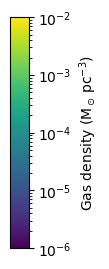

In [15]:
import matplotlib.colorbar as colorbar
import matplotlib.colors as mcolors

# Set up the normalization for the logarithmic scale
norm = mcolors.LogNorm(vmin=1e-6, vmax=1e-2)

# Create a color bar with a colormap (e.g., 'viridis')
fig, ax = plt.subplots(figsize=(0.5, 3))  # Adjust the size for a vertical color bar
fig.subplots_adjust(right=0.5)

# Create a scalar mappable object to connect the colormap with the color bar
cbar = colorbar.ColorbarBase(ax, cmap='viridis', norm=norm, orientation='vertical')

# Add a label for clarity
cbar.set_label(r'Gas density $({\rm M_\odot\,pc^{-3}})$')

# plt.savefig('/Users/ybchen/Downloads/colorbar.png', dpi=300, bbox_inches ='tight')
plt.show()

NGC_1851 NGC 1851 GC mass = 2.81e+05 Msun, Rperi = 0.90 kpc, Rapo = 19.90 kpc
integrated orbit: Rperi = 0.58 kpc, Rapo = 21.09 kpc
width in pc = 131.47837653435792
mass loss rates = [5.80285671 8.11549871]
mass loss rate = 6.893 Msun/Myr
mass loss rate / mass = 2.453e-05 1/Myr
rh / rt = 0.026

NGC_2298 NGC 2298 GC mass = 5.72e+04 Msun, Rperi = 0.97 kpc, Rapo = 16.49 kpc
integrated orbit: Rperi = 1.03 kpc, Rapo = 16.93 kpc
width in pc = 61.881585744635856
mass loss rates = [17.06622297 10.89288065]
mass loss rate = 13.172 Msun/Myr
mass loss rate / mass = 2.303e-04 1/Myr
rh / rt = 0.044

NGC_2808 NGC 2808 GC mass = 8.69e+05 Msun, Rperi = 1.08 kpc, Rapo = 14.60 kpc
integrated orbit: Rperi = 0.65 kpc, Rapo = 15.44 kpc
width in pc = 99.71520456261423
mass loss rates = [50.29853829 88.79963076]
mass loss rate = 66.088 Msun/Myr
mass loss rate / mass = 7.605e-05 1/Myr
rh / rt = 0.023

NGC_288 NGC 288 GC mass = 9.84e+04 Msun, Rperi = 1.93 kpc, Rapo = 12.34 kpc
integrated orbit: Rperi = 2.14 kpc

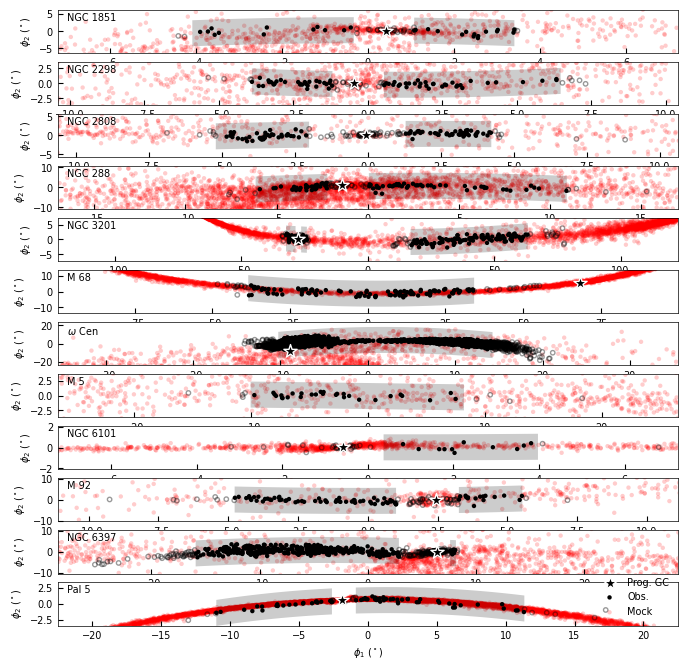

In [275]:
# longer integration

G_limit = 19
t_tot = 8000 * u.Myr
dt = 1 * u.Myr
n_steps = int(t_tot/dt)

center_on_poly = False

Tfrac = 0.05
N = 4000

f_rtid = 1
f_width = 6

n_obs_list = []
rate_list = []
mgc_list = []
ratio_list = []
T_list = []

# for age plot
length_list = []
width_list = []
ranges_list = []
x_age_list = []
y16_age_list = []
y84_age_list = []

class GreatCircle(coord.BaseCoordinateFrame):
    default_representation = coord.SphericalRepresentation
    default_differential = coord.SphericalCosLatDifferential

    frame_specific_representation_info = {
        coord.SphericalRepresentation: [
            coord.RepresentationMapping('lon', 'phi1'),
            coord.RepresentationMapping('lat', 'phi2'),
            coord.RepresentationMapping('distance', 'distance'),
        ]
    }

fig, axs = plt.subplots(len(gc_stream_ids), 1, figsize=(8,16), sharex=False, sharey=False)

for i in range(len(gc_stream_ids)):
    ax = axs[i]
    c = c_list[i]
    
    ax.text(0.015, 0.94, display_name_convert(gc_stream_list[i]), 
        va='top', ha='left', transform=ax.transAxes)
    
    c_gc = c.transform_to(coord.Galactocentric()).cartesian
    gc_w0 = gd.PhaseSpacePosition(c_gc)
    gc_mass = 10**mass_mw[np.where(name_mass_mw == gc_stream_list[i])[0][0]] * u.Msun
    print('%s %s GC mass = %.2e Msun, Rperi = %.2f kpc, Rapo = %.2f kpc'%(
        gc_stream_list[i], display_name_convert(gc_stream_list[i]), 
        gc_mass.value, data_mw['RPERI'][idx_with_stream][i], data_mw['RAPO'][idx_with_stream][i]))
    gc_pot = gp.PlummerPotential(m=gc_mass, b=4*u.pc, units=galactic)

    df = ms.ChenStreamDF(random_state=np.random.RandomState(0))
    gen = ms.MockStreamGenerator(df, pot, progenitor_potential=gc_pot)
    # stream, _ = gen.run(gc_w0, gc_mass, dt=-dt, n_steps=n_steps)
    
    orbit = pot.integrate_orbit(gc_w0, dt=-dt, n_steps=n_steps)
    
    pos = orbit.pos.xyz.value.T
    vel = orbit.vel.d_xyz.to('km/s').value.T

    r = np.sqrt(pos[:,0]**2 + pos[:,1]**2 + pos[:,2]**2)
    print('integrated orbit: Rperi = %.2f kpc, Rapo = %.2f kpc'%(np.min(r), np.max(r)))
    
    apos, peris = get_peri_apo(pos[:,0], pos[:,1], pos[:,2])
    T = np.mean(peris[1:] - peris[:-1])
    T_list.append(T*dt.value)
    Tsig = Tfrac * T
    rate = np.zeros(n_steps+1)
    for peri in peris:
        t_to_peri2 = (np.arange(n_steps+1) - peri)**2
        rate += 0.398942/Tsig*np.exp(-0.5*t_to_peri2/Tsig**2)/len(peris)
    
    rate = np.round(rate*N/np.sum(rate)).astype(int)
    
    stream, _ = gen.run(gc_w0, gc_mass, dt=-dt, n_steps=n_steps, n_particles=rate[::-1])
    stream_c = stream.to_coord_frame(coord.ICRS())

    @frame_transform_graph.transform(coord.StaticMatrixTransform, coord.ICRS, GreatCircle)
    def icrs_to_GreatCircle():
        return mat_stream_list[i]
    
    @frame_transform_graph.transform(coord.StaticMatrixTransform, GreatCircle, coord.ICRS)
    def GreatCircle_to_icrs():
        return matrix_transpose(mat_stream_list[i])
    
    stream_GreatCircle = stream_c.transform_to(GreatCircle())
    c_GreatCircle = c.transform_to(GreatCircle())

    # plot the progenitor GC
    phi1_gc = c_GreatCircle.phi1.wrap_at(180*u.deg).value
    phi2_gc  = c_GreatCircle.phi2.value
    if center_on_poly:
        ax.scatter(phi1_gc, phi2_gc-fit_poly(phi1_gc), s=100, marker='*', fc='k', ec='w', lw=1, zorder=100, label='Prog. GC')
    else:
        ax.scatter(phi1_gc, phi2_gc, s=100, marker='*', fc='k', ec='w', lw=1, zorder=100, label='Prog. GC')

    idx_structure = np.where(data_structure_mw['Cluster'] == gc_stream_list[i])[0]
    assert len(idx_structure) == 1
    rtid = data_structure_mw['rt'][idx_structure[0]]
    angle_rtid = (rtid / c_GreatCircle.distance.to('pc').value)*180/np.pi
        
    mask = (d['stream_id'] == gc_stream_ids[i]) & (d['G']<=G_limit)
    stream_obs_c = coord.ICRS(ra=d['ra'][mask]*u.deg, dec=d['dec'][mask]*u.deg)
    stream_obs_GreatCircle = stream_obs_c.transform_to(GreatCircle())

    phi1_obs = stream_obs_GreatCircle.phi1.wrap_at(180*u.deg).value
    phi2_obs = stream_obs_GreatCircle.phi2.value

    p = np.polyfit(phi1_obs, phi2_obs, deg=2)
    x = np.arange(-100,100,1)
    fit_poly = np.poly1d(p)
    width = np.sqrt(np.mean((phi2_obs-fit_poly(phi1_obs))**2))
    
    mask_left = (phi1_obs<phi1_gc-f_rtid*angle_rtid) & (phi2_obs-fit_poly(phi1_obs)>-f_width*width) & (phi2_obs-fit_poly(phi1_obs)<f_width*width)
    mask_right = (phi1_obs>phi1_gc+f_rtid*angle_rtid) & (phi2_obs-fit_poly(phi1_obs)>-f_width*width) & (phi2_obs-fit_poly(phi1_obs)<f_width*width)
    mask_lr = np.zeros_like(mask_left, dtype=bool)

    ranges = []
    masks = []
    if len(phi1_obs[mask_left]) >= 10:
        r = np.percentile(phi1_obs[mask_left], [10,90])
        ranges.append(r)
        mask_lr |= (mask_left & (phi1_obs>r[0]) & (phi1_obs<r[1]))
        masks.append((mask_left & (phi1_obs>r[0]) & (phi1_obs<r[1])))
    if len(phi1_obs[mask_right]) >= 10:
        r = np.percentile(phi1_obs[mask_right], [10,90])
        ranges.append(r)
        mask_lr |= (mask_right & (phi1_obs>r[0]) & (phi1_obs<r[1]))
        masks.append((mask_right & (phi1_obs>r[0]) & (phi1_obs<r[1])))
    # special treatment with omega cen, its GC is off center
    if gc_stream_list[i] == 'NGC_5139':
        r = np.percentile(phi1_obs, [10,90])
        ranges = [r]
        mask_lr = (phi2_obs-fit_poly(phi1_obs)>-f_width*width) & (phi2_obs-fit_poly(phi1_obs)<f_width*width) &  (phi1_obs>r[0]) & (phi1_obs<r[1])
        masks = [mask_lr]
    # special treatment with 3201, it has 3 segments
    if gc_stream_list[i] == 'NGC_3201':
        r = np.percentile(phi1_obs[mask_left], [10,90])
        ranges = [r]
        mask_right1 = mask_right & (phi1_obs<0)
        r = np.percentile(phi1_obs[mask_right1], [10,90])
        ranges.append(r)
        mask_right2 = mask_right & (phi1_obs>0)
        r = np.percentile(phi1_obs[mask_right2], [10,90])
        ranges.append(r)
        masks = [(mask_left & (phi1_obs>ranges[0][0]) & (phi1_obs<ranges[0][1])), 
            (mask_right1 & (phi1_obs>ranges[1][0]) & (phi1_obs<ranges[1][1])),
            (mask_right2 & (phi1_obs>ranges[2][0]) & (phi1_obs<ranges[2][1]))]
        mask_lr = ((mask_left & (phi1_obs>ranges[0][0]) & (phi1_obs<ranges[0][1])) | 
            (mask_right1 & (phi1_obs>ranges[1][0]) & (phi1_obs<ranges[1][1])) |
            (mask_right2 & (phi1_obs>ranges[2][0]) & (phi1_obs<ranges[2][1])))

    # if not center_on_poly:
    #     ax.plot(x, fit_poly(x), c='k', lw=2, alpha=0.6)

    # plot the obs. stars
    length = np.sqrt(np.mean(phi1_obs**2))
    if center_on_poly:
        ax.scatter(phi1_obs[~mask_lr], phi2_obs[~mask_lr]-fit_poly(phi1_obs[~mask_lr]), s=10, alpha=0.4, ec='k', fc='none', lw=1)
        ax.scatter(phi1_obs[mask_lr], phi2_obs[mask_lr]-fit_poly(phi1_obs[mask_lr]), s=10, alpha=1, ec='none', fc='k', label='Obs.')
        # ax.fill_between([-2*length, 2*length], [f_width*width, f_width*width], [-f_width*width, -f_width*width], ec='none', fc='k', alpha=0.2)
        for range in ranges:
            ax.fill_between(range, [f_width*width, f_width*width], [-f_width*width, -f_width*width], ec='none', fc='k', alpha=0.2)
    else:
        ax.scatter(phi1_obs[~mask_lr], phi2_obs[~mask_lr], s=10, alpha=0.4, ec='k', fc='none', lw=1)
        ax.scatter(phi1_obs[mask_lr], phi2_obs[mask_lr], s=10, alpha=1, ec='none', fc='k', label='Obs.')
        x = np.linspace(-2*length, 2*length,100)
        # ax.fill_between(x, fit_poly(x)+f_width*width, fit_poly(x)-f_width*width, ec='none', fc='k', alpha=0.2)
        for r in ranges:
            x = np.linspace(r[0], r[1],100)
            ax.fill_between(x, fit_poly(x)+f_width*width, fit_poly(x)-f_width*width, ec='none', fc='k', alpha=0.2)

    phi1_spray = stream_GreatCircle.phi1.wrap_at(180*u.deg).value
    phi2_spray = stream_GreatCircle.phi2.value
    # plot the mock stars
    if center_on_poly:
        ax.scatter(phi1_spray, phi2_spray-fit_poly(phi1_spray), s=10, alpha=0.2, fc='r', ec='none', label='Mock', zorder=0)
    else:
        ax.scatter(phi1_spray, phi2_spray, s=10, alpha=0.2, fc='r', ec='none', label='Mock', zorder=0)
    
    # compute the density for simulated streams
    num_in_range = 0
    length_in_range = 0
    density_spray_ranges = []
    for r in ranges:
        d_phi2 = phi2_spray-fit_poly(phi1_spray)
        width_spray = np.sqrt(np.mean((phi2_spray-fit_poly(phi1_spray))**2))
        weight = np.exp(-0.5*(d_phi2/width)**2) / np.exp(-0.5*(d_phi2/width_spray)**2)
        mask_in_range = (
            (phi1_spray>r[0]) & 
            (phi1_spray<=r[1]) & 
            (d_phi2>-f_width*width) & 
            (d_phi2<f_width*width)
        )
        # num_in_range += len(phi1_spray[mask_in_range])
        num_in_range += np.sum(weight[mask_in_range])
        length_in_range += r[1] - r[0]
        density_spray_ranges.append(np.sum(weight[mask_in_range])/(r[1]-r[0]))
    density_spray_ranges = np.array(density_spray_ranges)
    density_spray = num_in_range / length_in_range

    # directly get Gabs from Ibata distance
    # dist = d['d'][mask]
    # G_abs_here = G_abs[mask]
    
    # interp Gabs from fitted track. Needed for Ibata+24
    dist = np.full_like(d['G'][mask], fill_value=data_mw['Rsun'][idx_with_stream][i])
    G_abs_here = d['G'][mask] - 5*(np.log10(dist)+2)
    print('width in pc =', 1e3*data_mw['Rsun'][idx_with_stream][i]*width*np.pi/180)

    # compute the density of obs stream between phi1_l and phi1_h
    comp = np.inf
    idx = np.nan
    for j in range(len(old_iso)):
        iso = old_iso[j]
        mask1 = iso['label'] <= 3
        color = iso['G_BPmag'][mask1][::-1]-iso['G_RPmag'][mask1][::-1]
        Gmag = iso['Gmag'][mask1][::-1]
    
        dcolor = d['BP-RP'][mask] - np.interp(G_abs_here, Gmag, color)
        dcolor = np.mean(dcolor**2)
        if dcolor < comp:
            comp = dcolor
            idx = j
    iso = old_iso[idx]
    mask1 = iso['label'] <= 3
    color = iso['G_BPmag'][mask1][::-1]-iso['G_RPmag'][mask1][::-1]
    Gmag = iso['Gmag'][mask1][::-1]
    Mini = iso['Mini'][mask1][::-1]
    masses = np.interp(G_abs_here, Gmag, Mini)

    mass_limit = np.interp(G_limit - 5*(np.log10(dist)+2), Gmag, Mini)
    weight = kroupa(0, np.max(Mini)) / kroupa(mass_limit, np.max(Mini))

    mass_obs = np.sum(masses[mask_lr] * weight[mask_lr])
    density_obs_ranges = []
    for mask_seg, r in zip(masks,ranges):
        density_obs_ranges.append(np.sum(masses[mask_seg] * weight[mask_seg])/(r[1]-r[0]))
    density_obs = mass_obs / length_in_range
    density_obs_ranges = np.array(density_obs_ranges)
    n_obs_list.append(len(masses[mask_lr]))

    print('mass loss rates =', density_obs_ranges/density_spray_ranges*N/t_tot.value)
    print('mass loss rate = %.3f Msun/Myr'%(density_obs/density_spray*N/t_tot.value))
    print('mass loss rate / mass = %.3e 1/Myr'%(density_obs/density_spray*N/t_tot.value/gc_mass.value))
    rate_list.append(density_obs/density_spray*N/t_tot.value)
    mgc_list.append(gc_mass.value)

    idx_structure = np.where(data_structure_mw['Cluster'] == gc_stream_list[i])[0]
    assert len(idx_structure) == 1
    ratio = data_structure_mw['rh,m'][idx_structure[0]] / data_structure_mw['rt'][idx_structure[0]]
    print('rh / rt = %.3f'%ratio)
    ratio_list.append(ratio)

    ax.set_ylabel(r'$\phi_2\ (^\circ)$')
    # ax.set_xlim(-20,20)
    # ax.set_ylim(-5,5)
    # if i == 0:
    #     ax.set_xlim(-100,20)
    #     ax.set_ylim(-20,20)
    # if i == 1:
    #     ax.set_xlim(-20,180)
    #     ax.set_ylim(-20,20)
    # if gc_stream_list[i] == 'NGC_5139':
    #     ax.set_xlim(-10,40)
    #     ax.set_ylim(-10,40)

    ax.set_xlim(-3.5*length,3.5*length)
    # if not center_on_poly:
    #     width = np.sqrt(np.mean(phi2_obs**2))
    ax.set_ylim(-10*width,10*width)
    # ax.legend(loc='upper left', frameon=False)
    print('')

    # collect data for age plot
    length_list.append(length)
    width_list.append(width)
    ranges_list.append(ranges)
    
    bins = np.linspace(np.min(ranges)-length,np.max(ranges)+length, 16+1)
    x_age = (bins[1:] + bins[:-1])/2
    mask_in_width = (phi2_spray-fit_poly(phi1_spray)>-f_width*width) & (phi2_spray-fit_poly(phi1_spray)<f_width*width)
    y16_age = binned_statistic(phi1_spray[mask_in_width], -stream.release_time[mask_in_width]/1e3, statistic=f16, bins=bins)[0]
    y84_age = binned_statistic(phi1_spray[mask_in_width], -stream.release_time[mask_in_width]/1e3, statistic=f84, bins=bins)[0]
    x_age_list.append(x_age)
    y16_age_list.append(y16_age)
    y84_age_list.append(y84_age)

ax.set_xlabel(r'$\phi_1\ (^\circ)$')
ax.legend(loc='lower right', frameon=False)
# plt.gca().set_aspect(1)
plt.show()

rate_long_list = np.array(rate_list)
mgc_long_list = np.array(mgc_list)
ratio_long_list = np.array(ratio_list)
T_long_list = np.array(T_list)
n_obs_long_list = np.array(n_obs_list)

# for age plot
length_long_list = np.array(length_list)
width_long_list = np.array(width_list)
x_age_long_list = np.array(x_age_list)
y16_age_long_list = np.array(y16_age_list)
y84_age_long_list = np.array(y84_age_list)

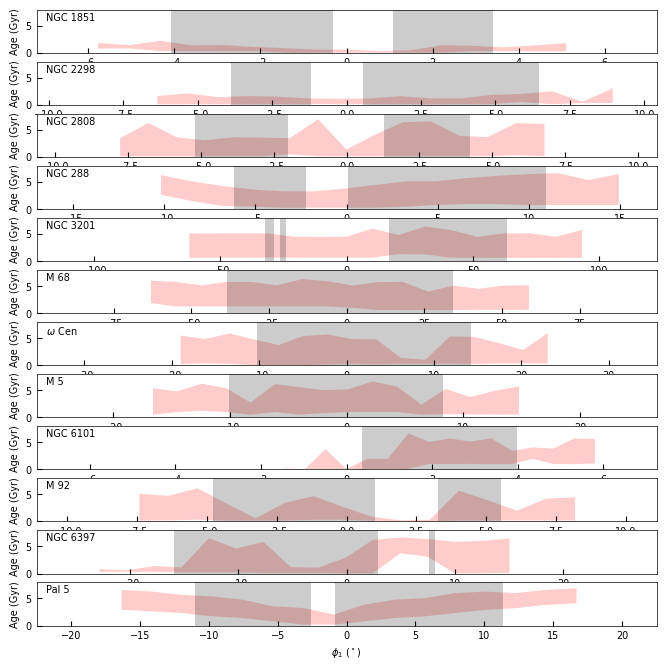

In [265]:

y_lim = 8 # Gyr

fig, axs = plt.subplots(len(gc_stream_ids), 1, figsize=(8,8), sharex=False, sharey=False)

for i in range(len(gc_stream_ids)):
    ax = axs[i]
    
    ax.text(0.015, 0.94, display_name_convert(gc_stream_list[i]), 
        va='top', ha='left', transform=ax.transAxes)
    
    ranges = ranges_list[i]
    x = x_age_long_list[i]
    y16 = y16_age_long_list[i]
    y84 = y84_age_long_list[i]
    length = length_long_list[i]
    
    # plt.scatter(phi1_spray, -stream.release_time)
    ax.fill_between(x, y16, y84, fc='r', ec='none', alpha=0.2)
    for r in ranges:
        ax.fill_between([r[0], r[1]], [0,0], [y_lim, y_lim], fc='k', ec='none', alpha=0.2)
    
    ax.set_ylim(0, y_lim)
    ax.set_ylabel(r'Age (Gyr)')
    
    ax.set_xlim(-3.5*length,3.5*length)

ax.set_xlabel(r'$\phi_1\ (^\circ)$')
plt.show()

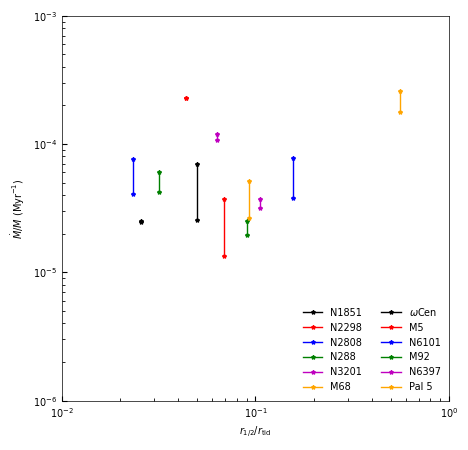

In [292]:

fig, axs = plt.subplots(1, 1, figsize=(5,5), sharex=False, sharey=False)

for i in range(len(gc_stream_ids)):
    # if i == 1:
    #     continue
    # plt.scatter(ratio_list[i], rate_list[i]/mgc_list[i], c=cs[i], s=10, marker='*', label=display_name_convert(gc_stream_list[i]))
    # err_rel = 1 / np.sqrt(n_obs_list[i])
    # plt.plot([ratio_list[i],ratio_list[i]], [(1-err_rel)*rate_list[i]/mgc_list[i],(1+err_rel)*rate_list[i]/mgc_list[i]], c=cs[i])

    plt.plot([ratio_list[i], ratio_list[i]], [rate_short_list[i]/mgc_list[i],rate_long_list[i]/mgc_list[i]], 
        c=cs[i], ms=3, marker='*', label=display_name_simple_convert(gc_stream_list[i]))

plt.xscale('log')
plt.yscale('log')

plt.xlabel(r'$r_{1/2}/r_{\rm tid}$')
plt.ylabel(r'$\dot{M}/M\ ({\rm Myr^{-1}})$')
plt.xlim(1e-2,1e0)
plt.ylim(1e-6,1e-3)

plt.legend(loc='lower right', frameon=False, ncol=2)
plt.show()

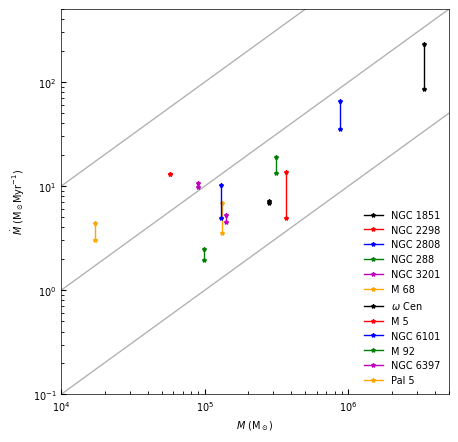

In [278]:

fig, axs = plt.subplots(1, 1, figsize=(5,5), sharex=False, sharey=False)

x = np.logspace(4,7,10+1)
# plt.plot(x, 30 * (x/2e5)**(1/3), c='k', ls='--', label=r'$(M/2e5)^{1/3}\times 30\,{\rm M_\odot Myr^{-1}}\ (R_{\rm eff}\sim 1~{\rm kpc})$')
# plt.plot(x, 3 * (x/2e5)**(1/3), c='k', label=r'$(M/2e5)^{1/3}\times 3\,{\rm M_\odot Myr^{-1}}\ (R_{\rm eff}\sim 10~{\rm kpc})$')

for i in range(len(gc_stream_ids)):
    # if i == 1:
    #     continue
    # plt.scatter(mgc_list[i], rate_list[i], c=cs[i], s=100, marker='*', label=gc_stream_list[i])
    plt.plot([mgc_list[i],mgc_list[i]], [rate_short_list[i],rate_long_list[i]], 
        c=cs[i], ms=3, marker='*', label=display_name_convert(gc_stream_list[i]))

plt.plot(x, x/1e3, c='k', alpha=0.3)
plt.plot(x, x/1e4, c='k', alpha=0.3)
plt.plot(x, x/1e5, c='k', alpha=0.3)

plt.xscale('log')
plt.yscale('log')

plt.xlabel(r'$M\ ({\rm M_\odot})$')
plt.ylabel(r'$\dot{M}\ ({\rm M_\odot Myr^{-1}})$')
plt.xlim(1e4,5e6)
plt.ylim(1e-1,5e2)

plt.legend(loc='lower right', frameon=False)
plt.show()

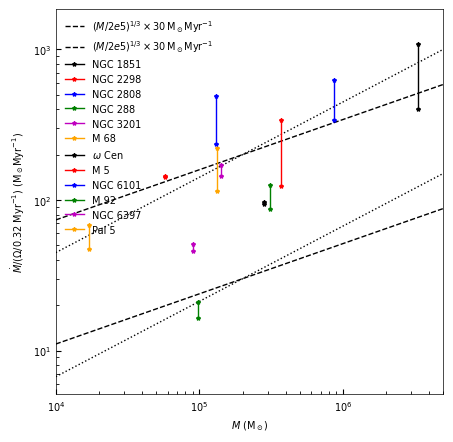

In [282]:

fig, axs = plt.subplots(1, 1, figsize=(5,5), sharex=False, sharey=False)

x = np.logspace(4,7,10+1)
plt.plot(x, 30 * (x/2e5)**(1/3), c='k', ls='--', label=r'$(M/2e5)^{1/3}\times 30\,{\rm M_\odot Myr^{-1}}$')
plt.plot(x, 30 * (x/2e5)**(1/2), c='k', ls=':')

plt.plot(x, 200 * (x/2e5)**(1/3), c='k', ls='--', label=r'$(M/2e5)^{1/3}\times 30\,{\rm M_\odot Myr^{-1}}$')
plt.plot(x, 200 * (x/2e5)**(1/2), c='k', ls=':')

for i in range(len(gc_stream_ids)):
    # if i == 1:
    #     continue
    idx_structure = np.where(data_structure_mw['Cluster'] == gc_stream_list[i])[0]
    assert len(idx_structure) == 1
    rh = data_structure_mw['rh,m'][idx_structure[0]]
    # plt.scatter(mgc_list[i], rate_list[i]/(2*np.pi/T_list[i]/0.32)/(rh/5)**(2/2), c=cs[i], s=100, marker='*', label=gc_stream_list[i])
    plt.plot([mgc_list[i],mgc_list[i]], np.array([rate_short_list[i],rate_long_list[i]])/(2*np.pi/T_list[i]/0.32), #/(rh/5)**(2/2), 
        c=cs[i], ms=3, marker='*', label=display_name_convert(gc_stream_list[i]))

plt.xscale('log')
plt.yscale('log')

plt.xlabel(r'$M\ ({\rm M_\odot})$')
plt.ylabel(r'$\dot{M}/(\Omega/0.32\ {\rm Myr^{-1}})\ ({\rm M_\odot Myr^{-1}})$')
plt.xlim(1e4,5e6)
# plt.ylim(1e1,2e2)

plt.legend(loc='upper left', frameon=False)
plt.show()

In [ ]:
def powerlaw_imf(a, m):
    return m**a

def integrate_powerlaw_imf(a, mmin, mmax):
    if a != -1:
        # int_mmin^mmax m^a dm = [mmax^(a+1) - mmin^(a+1)]/(a+1)
        return (mmax**(a+1) - mmin**(a+1))/(a+1)
    else:
        return np.log(mmax) - np.log(mmin)


def resample_powerlaw_imf(a, mmin, mmax, M, rng):
    m_mean = integrate_powerlaw_imf(a+1, mmin, mmax) / integrate_powerlaw_imf(a, mmin, mmax)
    N = int(M / m_mean)
    
    x = rng.uniform(size=N)
    if a != -1:
        return ((mmax**(a+1) - mmin**(a+1)) * x +mmin**(a+1))**(1/(a+1))
    else:
        return np.exp(x*(np.log(mmax)-np.log(mmin))+np.log(mmin))

In [ ]:
G_limit = 18
t_tot = 2000 * u.Myr
dt = 1 * u.Myr
n_steps = int(t_tot/dt)

Tfrac = 0.05
N = 1000

rate_list = []
mgc_list = []
ratio_list = []
T_list = []

class GreatCircle(coord.BaseCoordinateFrame):
    default_representation = coord.SphericalRepresentation
    default_differential = coord.SphericalCosLatDifferential

    frame_specific_representation_info = {
        coord.SphericalRepresentation: [
            coord.RepresentationMapping('lon', 'phi1'),
            coord.RepresentationMapping('lat', 'phi2'),
            coord.RepresentationMapping('distance', 'distance'),
        ]
    }

fig, axs = plt.subplots(len(gc_stream_ids), 1, figsize=(12,12), sharex=False, sharey=False)

for i in [5]:
    ax = axs[i]
    
    c = coord.ICRS(ra=data_mw['RA'][idx_with_stream][i] * u.deg, dec=data_mw['DEC'][idx_with_stream][i] * u.deg,
        distance=data_mw['Rsun'][idx_with_stream][i] * u.kpc,
        pm_ra_cosdec=data_mw['mu_alpha'][idx_with_stream][i] * u.mas/u.yr,
        pm_dec=data_mw['mu_delta'][idx_with_stream][i] * u.mas/u.yr,
        radial_velocity=data_mw['<RV>'][idx_with_stream][i] * u.km/u.s)
    
    c_gc = c.transform_to(coord.Galactocentric()).cartesian
    gc_w0 = gd.PhaseSpacePosition(c_gc)
    gc_mass = 10**mass_mw[np.where(name_mass_mw == gc_stream_list[i])[0][0]] * u.Msun
    print('%s GC mass = %.2e Msun, Rperi = %.2f kpc, Rapo = %.2f kpc'%(
        gc_stream_list[i], gc_mass.value, data_mw['RPERI'][idx_with_stream][i], data_mw['RAPO'][idx_with_stream][i]))
    gc_pot = gp.PlummerPotential(m=gc_mass, b=4*u.pc, units=galactic)

    df = ms.ChenStreamDF()
    gen = ms.MockStreamGenerator(df, pot, progenitor_potential=gc_pot)
    # stream, _ = gen.run(gc_w0, gc_mass, dt=-dt, n_steps=n_steps)
    
    orbit = pot.integrate_orbit(gc_w0, dt=-dt, n_steps=n_steps)
    
    pos = orbit.pos.xyz.value.T
    vel = orbit.vel.d_xyz.to('km/s').value.T

    r = np.sqrt(pos[:,0]**2 + pos[:,1]**2 + pos[:,2]**2)
    print('integrated orbit: Rperi = %.2f kpc, Rapo = %.2f kpc'%(np.min(r), np.max(r)))
    
    apos, peris = get_peri_apo(pos[:,0], pos[:,1], pos[:,2])
    T = np.mean(peris[1:] - peris[:-1])
    T_list.append(T*dt.value)
    Tsig = Tfrac * T
    rate = np.zeros(n_steps+1)
    for peri in peris:
        t_to_peri2 = (np.arange(n_steps+1) - peri)**2
        rate += 0.398942/Tsig*np.exp(-0.5*t_to_peri2/Tsig**2)/len(peris)
    
    rate = np.round(rate*N/np.sum(rate)).astype(int)
    
    stream, _ = gen.run(gc_w0, gc_mass, dt=-dt, n_steps=n_steps, n_particles=rate[::-1])




    stream_c = stream.to_coord_frame(coord.ICRS())

    # rotate to great circle frame

    # step 1: rotate the GC to center
    GreatCircle_MATRIX = rotation_matrix(ra_wrap_at_180[idx_with_stream][i]*u.deg, 'z')
    GreatCircle_MATRIX = rotation_matrix(-data_mw['DEC'][idx_with_stream][i]*u.deg, 'y') @ GreatCircle_MATRIX
    
    @frame_transform_graph.transform(coord.StaticMatrixTransform, coord.ICRS, GreatCircle)
    def icrs_to_GreatCircle():
        return GreatCircle_MATRIX
    
    @frame_transform_graph.transform(coord.StaticMatrixTransform, GreatCircle, coord.ICRS)
    def GreatCircle_to_icrs():
        return matrix_transpose(GreatCircle_MATRIX)
    
    # step 2: align the frame
    # method 1: align the GC's velocity
    # c_GreatCircle = c.transform_to(GreatCircle())
    # rotate = np.arctan2(c_GreatCircle.pm_phi2, c_GreatCircle.pm_phi1_cosphi2).to('deg').value
    # GreatCircle_MATRIX = rotation_matrix(rotate*u.deg, 'x') @ GreatCircle_MATRIX
    
    # method 2: align the stream stars
    mask = (d['stream_id'] == gc_stream_ids[i]) & (d['G']<=G_limit)
    stream_obs_c = coord.ICRS(ra=d['ra'][mask]*u.deg, dec=d['dec'][mask]*u.deg)
    stream_obs_GreatCircle = stream_obs_c.transform_to(GreatCircle())
    rad = np.sqrt(stream_obs_GreatCircle.phi1.wrap_at(180*u.deg).value**2+stream_obs_GreatCircle.phi2.value**2)
    z = np.polyfit(stream_obs_GreatCircle.phi1.wrap_at(180*u.deg).value[rad<50], stream_obs_GreatCircle.phi2.value[rad<50], deg=1)
    if gc_stream_list[i] == 'NGC_5139':
        z = np.polyfit(stream_obs_GreatCircle.phi1.wrap_at(180*u.deg).value[rad<50], stream_obs_GreatCircle.phi2.value[rad<50], deg=1)
    rotate = np.arctan(z[0])
    GreatCircle_MATRIX = rotation_matrix(rotate*u.rad, 'x') @ GreatCircle_MATRIX
    
    @frame_transform_graph.transform(coord.StaticMatrixTransform, coord.ICRS, GreatCircle)
    def icrs_to_GreatCircle():
        return GreatCircle_MATRIX
    
    @frame_transform_graph.transform(coord.StaticMatrixTransform, GreatCircle, coord.ICRS)
    def GreatCircle_to_icrs():
        return matrix_transpose(GreatCircle_MATRIX)
    
    stream_GreatCircle = stream_c.transform_to(GreatCircle())
    c_GreatCircle = c.transform_to(GreatCircle())
    
    stream_obs_GreatCircle = stream_obs_c.transform_to(GreatCircle())

    phi1_obs = stream_obs_GreatCircle.phi1.wrap_at(180*u.deg).value
    phi2_obs = stream_obs_GreatCircle.phi2.value
    ax.scatter(phi1_obs, phi2_obs, s=10, alpha=1, fc=cs[i])

    # compute the density between phi1_l and phi1_h
    if i == 0:
        phi1_l, phi1_h = np.percentile(phi1_obs[phi1_obs<0], [10,90])
    elif i == 1:
        phi1_l, phi1_h = np.percentile(phi1_obs[phi1_obs>0], [10,90])
    else:
        phi1_l, phi1_h = np.percentile(phi1_obs[phi1_obs>0], [10,90])
    ax.vlines([phi1_l, phi1_h], -20, 20, color='k', alpha=0.5)

    comp = np.inf
    idx = np.nan
    
    for j in range(len(old_iso)):
        iso = old_iso[j]
        mask1 = iso['label'] <= 3
        color = iso['G_BPmag'][mask1][::-1]-iso['G_RPmag'][mask1][::-1]
        Gmag = iso['Gmag'][mask1][::-1]
    
        dcolor = d['BP-RP'][mask] - np.interp(G_abs[mask], Gmag, color)
        dcolor = np.mean(dcolor**2)
        if dcolor < comp:
            comp = dcolor
            idx = j
        
    iso = old_iso[idx]
    mask1 = iso['label'] <= 3
    color = iso['G_BPmag'][mask1][::-1]-iso['G_RPmag'][mask1][::-1]
    Gmag = iso['Gmag'][mask1][::-1]
    Mini = iso['Mini'][mask1][::-1]
    masses = np.interp(G_abs[mask], Gmag, Mini)

    mass_limit = np.interp(G_limit - 5*(np.log10(d['d'][mask])+2), Gmag, Mini)
    weight = kroupa(0, np.max(Mini)) / kroupa(mass_limit, np.max(Mini))
    a = -1.5
    weight = integrate_powerlaw_imf(a+1, 0, np.max(Mini)) / integrate_powerlaw_imf(a+1, mass_limit, np.max(Mini))

    mask_arm = (phi1_obs>phi1_l) & (phi1_obs<=phi1_h)
    mass_obs = np.sum(masses[mask_arm] * weight[mask_arm])
    density_obs = mass_obs / (phi1_h - phi1_l)

    phi1_spray = stream_GreatCircle.phi1.wrap_at(180*u.deg).value
    phi2_spray = stream_GreatCircle.phi2.value
    ax.scatter(phi1_spray, phi2_spray, s=10, alpha=0.1, fc=cs[i])
    ax.scatter(c_GreatCircle.phi1.wrap_at(180*u.deg),c_GreatCircle.phi2, s=400, marker='*', fc=cs[i], ec='w', lw=2, label=gc_stream_list[i])

    # compute the density between phi1_l and phi1_h for simulated streams
    phi2_l = -5
    phi2_h = 5
    if i == 1 or i == 0:
        phi2_l = -20
        phi2_h = 20
    if gc_stream_list[i] == 'NGC_5139':
        phi2_l = 0
        phi2_h = 40
    density_spray = len(phi1_spray[(phi1_spray>phi1_l) & (phi1_spray<=phi1_h) & (phi2_spray>phi2_l) & (phi2_spray<=phi2_h)]) / (phi1_h - phi1_l)

    print('mass loss rate = %.3f Msun/Myr'%(density_obs/density_spray*N/t_tot.value))
    print('mass loss rate / mass = %.3e 1/Myr'%(density_obs/density_spray*N/t_tot.value/gc_mass.value))
    rate_list.append(density_obs/density_spray*N/t_tot.value)
    mgc_list.append(gc_mass.value)

    idx_structure = np.where(data_structure_mw['Cluster'] == gc_stream_list[i])[0]
    assert len(idx_structure) == 1
    ratio = data_structure_mw['rh,m'][idx_structure[0]] / data_structure_mw['rt'][idx_structure[0]]
    print('rh / rt = %.3f'%ratio)
    ratio_list.append(ratio)

    # resampling
    rng = np.random.default_rng(i)
    mass_obs_resample_list = []
    N_obs_resample_list = []
    for repeat in range(1000):
        m_limit = 0.5
        mass_obs_above_limit = mass_obs * integrate_powerlaw_imf(a+1, m_limit, np.max(Mini)) / integrate_powerlaw_imf(a+1, 0, np.max(Mini))
        m = resample_powerlaw_imf(a, m_limit, np.max(Mini), mass_obs_above_limit, rng)
        G_abs_resample = np.interp(m, Mini[::-1], Gmag[::-1])
    
        # assume resamples have the same radius
        d_array = np.full_like(m, fill_value=np.mean(d['d'][mask]))
        G_mag_resample = G_abs_resample + 5*(np.log10(d_array)+2)
        mass_limit = np.interp(G_limit - 5*(np.log10(d_array)+2), Gmag, Mini)
        weight = integrate_powerlaw_imf(a+1, 0, np.max(Mini)) / integrate_powerlaw_imf(a+1, mass_limit, np.max(Mini))
        mass_obs_resample = np.sum(m[G_mag_resample<=G_limit] * weight[G_mag_resample<=G_limit])
        # print(mass_obs, mass_obs_resample)
        mass_obs_resample_list.append(mass_obs_resample)
        N_obs_resample_list.append(len(m[G_mag_resample<=G_limit]))
    
    ax.set_xlabel(r'$\phi_1\ (^\circ)$')
    ax.set_ylabel(r'$\phi_2\ (^\circ)$')
    ax.set_xlim(-20,20)
    ax.set_ylim(-5,5)
    if i == 0:
        ax.set_xlim(-100,20)
        ax.set_ylim(-20,20)
    if i == 1:
        ax.set_xlim(-20,180)
        ax.set_ylim(-20,20)
    if gc_stream_list[i] == 'NGC_5139':
        ax.set_xlim(-10,40)
        ax.set_ylim(-10,40)
        
    ax.legend(loc='upper left', frameon=False)
    print('')
# plt.gca().set_aspect(1)
plt.show()

rate_list = np.array(rate_list)
mgc_list = np.array(mgc_list)
ratio_list = np.array(ratio_list)
T_list = np.array(T_list)

In [ ]:
from scipy.special import gamma

bins = np.linspace(4000, 16000, 23)
plt.hist(mass_obs_resample_list, bins=bins, histtype='step', density=True)
# plt.hist(mass_obs_resample_list, bins=200, histtype='step', density=True)
# plt.vlines(mass_obs, 0, 25, color='r')

N_obs = len(masses[mask_arm])
m_mean = mass_obs / N_obs
n = np.arange(2*N_obs, dtype=int)
x = m_mean * n
pois = poisson(N_obs)
y_poisson = pois.pmf(n)/m_mean

plt.plot(x, y_poisson)

plt.xlim(np.min(mass_obs_resample_list), np.max(mass_obs_resample_list))

In [41]:
-0.7*0.35*(20*np.pi/180)

-0.08552113334772213

In [43]:
30.1*np.pi/180

0.5253441048502933